# ROGII Wellbore Geology Prediction

## Notebook 04 – Baseline Models and Validation

### Objectives

- Establish simple baseline methods for predicting the missing TVT values.
- Create a reliable validation pipeline using complete well pairs.
- Evaluate prediction performance only within the hidden prediction section.
- Compare multiple baseline approaches using MAE and RMSE.
- Assess how well recent TVT trends can predict future TVT.
- Investigate whether well trajectory (Z) can be used to estimate TVT.
- Evaluate the usefulness of formation-marker columns as prediction references.
- Identify wells that are easy and difficult to predict.
- Establish benchmark scores for future machine learning models.
- Select the strongest baseline to compare against advanced models in subsequent notebooks.

### 1. Import Libraries

In [24]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

### 2. Configure Project Paths

In [25]:
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"

TRAIN_DIR = RAW_DIR / "train"

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project root:", PROJECT_ROOT.resolve())
print("Training directory:", TRAIN_DIR.resolve())
print("Training directory exists:", TRAIN_DIR.exists())
print("Processed directory exists:", PROCESSED_DIR.exists())

Project root: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology
Training directory: C:\Dev\Rogii Wellbore Geology\rogii-wellbore-geology\data\raw\train
Training directory exists: True
Processed directory exists: True


### 3. Discover Training Well Pairs

In [26]:
typewell_files = sorted(
    TRAIN_DIR.glob("*_typewell.csv")
)

horizontal_files = sorted(
    TRAIN_DIR.glob("*_horizontal_well.csv")
)

typewell_map = {
    file.name.replace("_typewell.csv", ""): file
    for file in typewell_files
}

horizontal_map = {
    file.name.replace("_horizontal_well.csv", ""): file
    for file in horizontal_files
}

typewell_ids = set(typewell_map)
horizontal_ids = set(horizontal_map)

complete_ids = sorted(
    typewell_ids & horizontal_ids
)

missing_horizontal_ids = sorted(
    typewell_ids - horizontal_ids
)

missing_typewell_ids = sorted(
    horizontal_ids - typewell_ids
)

print("Typewell files:", len(typewell_files))
print("Horizontal-well files:", len(horizontal_files))
print("Complete well pairs:", len(complete_ids))
print("Missing horizontal wells:", len(missing_horizontal_ids))
print("Missing typewells:", len(missing_typewell_ids))

Typewell files: 773
Horizontal-well files: 773
Complete well pairs: 773
Missing horizontal wells: 0
Missing typewells: 0


#### 3.1 Validate Required Columns

Before modelling, the notebook checks whether all required columns exist in each file type. This prevents errors later in the baseline evaluation process.

In [27]:
TYPEWELL_REQUIRED_COLUMNS = [
    "TVT",
    "GR",
    "Geology"
]

HORIZONTAL_REQUIRED_COLUMNS = [
    "MD",
    "X",
    "Y",
    "Z",
    "GR",
    "TVT",
    "TVT_input"
]

FORMATION_COLUMNS = [
    "ANCC",
    "ASTNU",
    "ASTNL",
    "EGFDU",
    "EGFDL",
    "BUDA"
]

In [28]:
def validate_well_columns(
    well_id,
    typewell_data,
    horizontal_data
):
    missing_typewell_columns = [
        column
        for column in TYPEWELL_REQUIRED_COLUMNS
        if column not in typewell_data.columns
    ]

    missing_horizontal_columns = [
        column
        for column in HORIZONTAL_REQUIRED_COLUMNS
        if column not in horizontal_data.columns
    ]

    return {
        "Well_ID": well_id,
        "Missing_Typewell_Columns": missing_typewell_columns,
        "Missing_Horizontal_Columns": missing_horizontal_columns,
        "Valid": (
            len(missing_typewell_columns) == 0
            and len(missing_horizontal_columns) == 0
        )
    }

#### 3.2 Test Loading One Well Pair

One representative pair is loaded before processing the complete dataset. This verifies that the paths, filenames, and expected columns are correct.

In [29]:
sample_id = complete_ids[0]

sample_typewell = pd.read_csv(
    typewell_map[sample_id]
)

sample_horizontal = pd.read_csv(
    horizontal_map[sample_id]
)

print("Sample well ID:", sample_id)
print("Typewell shape:", sample_typewell.shape)
print("Horizontal-well shape:", sample_horizontal.shape)

display(sample_typewell.head())
display(sample_horizontal.head())

Sample well ID: 000d7d20_
Typewell shape: (1296, 3)
Horizontal-well shape: (5278, 13)


,TVT,GR,Geology
0,"11,223.9500",126.1100,NaN
1,"11,224.4500",128.2200,NaN
2,"11,224.9500",128.7200,NaN
3,"11,225.4500",128.1200,NaN
4,"11,225.9500",125.2900,NaN


,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
0,"11,467.0000","2,983,525.1600","1,069,022.0900","-9,258.5700","-9,395.8100","-9,569.8600","-9,597.6400","-9,670.9900","-9,705.9600","-9,846.3500","11,236.0200",115.6926,"11,236.0200"
1,"11,468.0000","2,983,525.1800","1,069,022.3000","-9,259.5500","-9,395.7500","-9,569.8000","-9,597.5800","-9,670.9300","-9,705.9000","-9,846.2900","11,237.0500",115.5843,"11,237.0500"
2,"11,469.0000","2,983,525.2000","1,069,022.5200","-9,260.5200","-9,395.6900","-9,569.7400","-9,597.5200","-9,670.8700","-9,705.8400","-9,846.2300","11,238.0900",135.4470,"11,238.0900"
3,"11,470.0000","2,983,525.2200","1,069,022.7300","-9,261.5000","-9,395.6400","-9,569.6900","-9,597.4700","-9,670.8200","-9,705.7900","-9,846.1800","11,239.1200",140.4013,"11,239.1200"
4,"11,471.0000","2,983,525.2500","1,069,022.9500","-9,262.4700","-9,395.5800","-9,569.6300","-9,597.4100","-9,670.7600","-9,705.7300","-9,846.1200","11,240.1500",111.2706,"11,240.1500"


#### 3.3 Validate the Sample Columns

In [30]:
sample_validation = validate_well_columns(
    sample_id,
    sample_typewell,
    sample_horizontal
)

display(
    pd.Series(sample_validation)
    .to_frame("Value")
)

,Value
Well_ID,000d7d20_
Missing_Typewell_Columns,[]
Missing_Horizontal_Columns,[]
Valid,True


### 4. Create Helper Functions

The baseline models need repeated operations such as identifying the prediction section, calculating recent trends, fitting simple linear relationships, and handling invalid values.

Helper functions make these operations reusable and keep the evaluation code organised.

#### 4.1 Identify Known and Prediction Sections

In [31]:
def identify_prediction_sections(horizontal_data):
    known_mask = horizontal_data["TVT_input"].notna()
    prediction_mask = horizontal_data["TVT_input"].isna()

    return known_mask, prediction_mask

In [32]:
sample_known_mask, sample_prediction_mask = (
    identify_prediction_sections(
        sample_horizontal
    )
)

print("Known rows:", sample_known_mask.sum())
print("Prediction rows:", sample_prediction_mask.sum())
print(
    "Total rows:",
    len(sample_horizontal)
)

Known rows: 1442
Prediction rows: 3836
Total rows: 5278


#### 4.2 Validate the Prediction Boundary

In [33]:
def has_clean_prediction_boundary(horizontal_data):
    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    prediction_positions = np.flatnonzero(
        prediction_mask.to_numpy()
    )

    if len(prediction_positions) == 0:
        return True

    prediction_start_position = int(
        prediction_positions[0]
    )

    known_before_start = known_mask.iloc[
        :prediction_start_position
    ].all()

    missing_after_start = prediction_mask.iloc[
        prediction_start_position:
    ].all()

    return bool(
        known_before_start
        and missing_after_start
    )

In [34]:
print(
    "Clean prediction boundary:",
    has_clean_prediction_boundary(
        sample_horizontal
    )
)

Clean prediction boundary: True


#### 4.3 Extract Prediction Information

In [35]:
def get_prediction_information(horizontal_data):
    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    known_positions = np.flatnonzero(
        known_mask.to_numpy()
    )

    prediction_positions = np.flatnonzero(
        prediction_mask.to_numpy()
    )

    if len(known_positions) == 0:
        raise ValueError(
            "The horizontal well contains no known TVT_input rows."
        )

    if len(prediction_positions) == 0:
        raise ValueError(
            "The horizontal well contains no prediction rows."
        )

    last_known_position = int(
        known_positions[-1]
    )

    prediction_start_position = int(
        prediction_positions[0]
    )

    return {
        "Known_Mask": known_mask,
        "Prediction_Mask": prediction_mask,
        "Known_Rows": int(known_mask.sum()),
        "Prediction_Rows": int(prediction_mask.sum()),
        "Last_Known_Position": last_known_position,
        "Prediction_Start_Position": prediction_start_position,
        "Last_Known_MD": horizontal_data.iloc[
            last_known_position
        ]["MD"],
        "Last_Known_TVT": horizontal_data.iloc[
            last_known_position
        ]["TVT_input"],
        "Prediction_Start_MD": horizontal_data.iloc[
            prediction_start_position
        ]["MD"]
    }

In [36]:
sample_prediction_information = (
    get_prediction_information(
        sample_horizontal
    )
)

display(
    pd.Series(
        {
            key: value
            for key, value
            in sample_prediction_information.items()
            if key not in [
                "Known_Mask",
                "Prediction_Mask"
            ]
        }
    ).to_frame("Value")
)

,Value
Known_Rows,"1,442.0000"
Prediction_Rows,"3,836.0000"
Last_Known_Position,"1,441.0000"
Prediction_Start_Position,"1,442.0000"
Last_Known_MD,"12,908.0000"
Last_Known_TVT,"11,747.3700"
Prediction_Start_MD,"12,909.0000"


#### 4.4 Calculate a Linear Slope

In [37]:
def calculate_recent_tvt_slope(
    horizontal_data,
    window=50
):
    known_mask, _ = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    recent_data = (
        horizontal_data
        .loc[
            known_mask,
            ["MD", "TVT_input"]
        ]
        .dropna()
        .tail(window)
    )

    if len(recent_data) < 2:
        return np.nan

    if recent_data["MD"].nunique() < 2:
        return np.nan

    slope, intercept = np.polyfit(
        recent_data["MD"],
        recent_data["TVT_input"],
        1
    )

    return {
        "Slope": slope,
        "Intercept": intercept,
        "Rows_Used": len(recent_data)
    }

In [38]:
sample_slope_information = (
    calculate_recent_tvt_slope(
        sample_horizontal,
        window=50
    )
)

display(
    pd.Series(
        sample_slope_information
    ).to_frame("Value")
)

,Value
Slope,0.0167
Intercept,"11,531.9203"
Rows_Used,50.0000


#### 4.5 Create Safe Linear Predictions

In [39]:
def fit_simple_linear_model(
    train_feature,
    train_target,
    prediction_feature
):
    training_data = pd.DataFrame({
        "Feature": train_feature,
        "Target": train_target
    }).dropna()

    if len(training_data) < 2:
        return None

    if training_data["Feature"].nunique() < 2:
        return None

    slope, intercept = np.polyfit(
        training_data["Feature"],
        training_data["Target"],
        1
    )

    prediction_values = (
        slope * prediction_feature
        + intercept
    )

    return {
        "Predictions": np.asarray(
            prediction_values,
            dtype=float
        ),
        "Slope": slope,
        "Intercept": intercept,
        "Training_Rows": len(training_data)
    }

#### 4.6 Validate Prediction Arrays

In [40]:
def prepare_valid_evaluation_data(
    actual_values,
    predicted_values
):
    evaluation_data = pd.DataFrame({
        "Actual": np.asarray(
            actual_values,
            dtype=float
        ),
        "Predicted": np.asarray(
            predicted_values,
            dtype=float
        )
    })

    evaluation_data = (
        evaluation_data
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .dropna()
    )

    return evaluation_data

### 5. Define Evaluation Metrics

The baseline methods are evaluated using Mean Absolute Error and Root Mean Squared Error.

#### Mean Absolute Error

MAE measures the average absolute distance between the predicted and actual TVT values.

A smaller MAE indicates better predictions.

#### Root Mean Squared Error

RMSE gives greater importance to large prediction errors.

A smaller RMSE indicates better predictions. A large difference between RMSE and MAE suggests that the model produces some unusually large errors.

#### 5.1 Create the Evaluation Function

In [41]:
def calculate_regression_metrics(
    actual_values,
    predicted_values
):
    evaluation_data = (
        prepare_valid_evaluation_data(
            actual_values,
            predicted_values
        )
    )

    if len(evaluation_data) == 0:
        return {
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "Evaluation_Rows": 0
        }

    actual = evaluation_data["Actual"]
    predicted = evaluation_data["Predicted"]

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    bias = (
        predicted - actual
    ).mean()

    return {
        "MAE": mae,
        "RMSE": rmse,
        "Bias": bias,
        "Evaluation_Rows": len(
            evaluation_data
        )
    }

#### 5.2 Test the Evaluation Function

In [42]:
test_actual = np.array([
    100,
    105,
    110,
    115
])

test_predicted = np.array([
    102,
    103,
    111,
    118
])

test_metrics = calculate_regression_metrics(
    test_actual,
    test_predicted
)

display(
    pd.Series(
        test_metrics
    ).to_frame("Value")
)

,Value
MAE,2.0000
RMSE,2.1213
Bias,1.0000
Evaluation_Rows,4.0000


#### 5.3 Validate the Actual Prediction Target

The complete `TVT` column is available in the training data so that predictions can be evaluated.

Only the rows where `TVT_input` is missing are used as the actual target during baseline evaluation.

In [43]:
sample_known_mask, sample_prediction_mask = (
    identify_prediction_sections(
        sample_horizontal
    )
)

sample_actual_target = (
    sample_horizontal
    .loc[
        sample_prediction_mask,
        "TVT"
    ]
)

print(
    "Prediction rows:",
    sample_prediction_mask.sum()
)

print(
    "Available target values:",
    sample_actual_target.notna().sum()
)

print(
    "Missing target values:",
    sample_actual_target.isna().sum()
)

Prediction rows: 3836
Available target values: 3836
Missing target values: 0


#### Important Data-Leakage Rule

The horizontal-well `TVT` column contains the correct target values for the complete training well.

It must never be used as a model input.

It may only be used:

- To select the actual TVT values in the prediction section.
- To calculate evaluation metrics after predictions have been created.

Using prediction-section `TVT` while creating a prediction would produce data leakage and unrealistic model performance.

### 6. Implement Baseline Model 1 – Last Known TVT

The first baseline predicts every missing TVT value using the final visible `TVT_input` value.

This method assumes that TVT remains constant after the prediction start.

It is a very simple baseline, but it provides an important minimum benchmark. Future models should normally perform better than this approach.

#### 6.1 Create the Last-Known-TVT Function

In [44]:
def predict_last_known_tvt(horizontal_data):
    prediction_information = get_prediction_information(
        horizontal_data
    )

    prediction_mask = prediction_information[
        "Prediction_Mask"
    ]

    last_known_tvt = prediction_information[
        "Last_Known_TVT"
    ]

    prediction_count = int(
        prediction_mask.sum()
    )

    predictions = np.full(
        prediction_count,
        last_known_tvt,
        dtype=float
    )

    return {
        "Predictions": predictions,
        "Last_Known_TVT": last_known_tvt,
        "Prediction_Rows": prediction_count
    }

#### 6.2 Test the Baseline on the Sample Well

The baseline is first tested on one representative horizontal well before applying it to all training wells.

In [45]:
sample_last_known_result = predict_last_known_tvt(
    sample_horizontal
)

print(
    "Last known TVT:",
    sample_last_known_result[
        "Last_Known_TVT"
    ]
)

print(
    "Prediction rows:",
    sample_last_known_result[
        "Prediction_Rows"
    ]
)

print(
    "First five predictions:",
    sample_last_known_result[
        "Predictions"
    ][:5]
)

Last known TVT: 11747.37
Prediction rows: 3836
First five predictions: [11747.37 11747.37 11747.37 11747.37 11747.37]


#### 6.3 Select the Actual Prediction Target

The true `TVT` values from the prediction section are used only to evaluate the baseline.

They are not used when generating predictions.

In [46]:
sample_prediction_mask = (
    sample_horizontal["TVT_input"].isna()
)

sample_actual_tvt = (
    sample_horizontal.loc[
        sample_prediction_mask,
        "TVT"
    ]
    .to_numpy()
)

print(
    "Actual target rows:",
    len(sample_actual_tvt)
)

print(
    "Predicted rows:",
    len(
        sample_last_known_result[
            "Predictions"
        ]
    )
)

Actual target rows: 3836
Predicted rows: 3836


#### 6.4 Evaluate the Baseline

The baseline is evaluated using MAE, RMSE, and prediction bias.

Lower MAE and RMSE values indicate better predictions.

In [47]:
sample_last_known_metrics = (
    calculate_regression_metrics(
        sample_actual_tvt,
        sample_last_known_result[
            "Predictions"
        ]
    )
)

display(
    pd.Series(
        sample_last_known_metrics
    ).to_frame("Value")
)

,Value
MAE,6.1350
RMSE,7.4544
Bias,5.4456
Evaluation_Rows,"3,836.0000"


#### 6.5 Visualize the Last-Known-TVT Prediction

The graph compares the actual TVT curve, the visible `TVT_input`, and the constant baseline prediction.

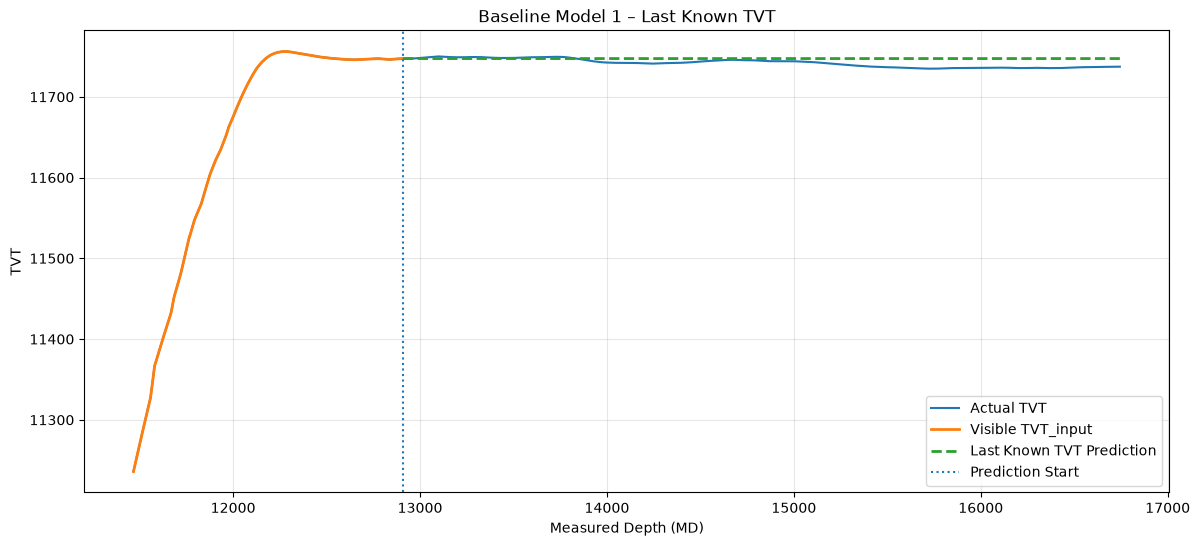

In [48]:
sample_last_known_full = np.full(
    len(sample_horizontal),
    np.nan
)

sample_last_known_full[
    sample_prediction_mask.to_numpy()
] = sample_last_known_result[
    "Predictions"
]

prediction_start_md = (
    sample_prediction_information[
        "Prediction_Start_MD"
    ]
)

plt.figure(figsize=(14, 6))

plt.plot(
    sample_horizontal["MD"],
    sample_horizontal["TVT"],
    linewidth=1.5,
    label="Actual TVT"
)

plt.plot(
    sample_horizontal["MD"],
    sample_horizontal["TVT_input"],
    linewidth=2,
    label="Visible TVT_input"
)

plt.plot(
    sample_horizontal["MD"],
    sample_last_known_full,
    linestyle="--",
    linewidth=2,
    label="Last Known TVT Prediction"
)

plt.axvline(
    prediction_start_md,
    linestyle=":",
    label="Prediction Start"
)

plt.title(
    "Baseline Model 1 – Last Known TVT"
)

plt.xlabel("Measured Depth (MD)")
plt.ylabel("TVT")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

#### Baseline 1 Observation

On the sample well, the Last Known TVT baseline holds a constant value of about 11,747 for all 3,836 prediction rows.

The plot shows why this works fairly well here. After Prediction Start, the true TVT stays almost flat and only drifts down a little. The green dashed line stays level, so it stays close to the blue actual curve for most of the well. The gap grows slowly toward the end as the true TVT dips slightly below the last known value.

For this well the scores are:

- MAE: 6.14
- RMSE: 7.45
- Bias: +5.45

The small positive bias means the constant prediction sits a bit above the true values on average. This is still a strong first benchmark for a nearly flat prediction section. Wells where TVT keeps rising or falling after Prediction Start should score worse with this method.

### 7. Implement Baseline Model 2 – Linear Extrapolation

This baseline predicts future TVT values by extending the recent visible TVT trend into the prediction section.

A straight line is fitted using the final known rows before the prediction start.

Several window sizes are tested because:

- A short window follows recent changes closely.
- A long window gives a more stable trend.
- Different wells may behave better with different window sizes.

#### 7.1 Create the Linear Extrapolation Function

In [49]:
def predict_linear_extrapolation(
    horizontal_data,
    window=50
):
    prediction_information = get_prediction_information(
        horizontal_data
    )

    known_mask = prediction_information[
        "Known_Mask"
    ]

    prediction_mask = prediction_information[
        "Prediction_Mask"
    ]

    recent_data = (
        horizontal_data.loc[
            known_mask,
            ["MD", "TVT_input"]
        ]
        .dropna()
        .tail(window)
    )

    if len(recent_data) < 2:
        return None

    if recent_data["MD"].nunique() < 2:
        return None

    slope, intercept = np.polyfit(
        recent_data["MD"],
        recent_data["TVT_input"],
        1
    )

    prediction_md = (
        horizontal_data.loc[
            prediction_mask,
            "MD"
        ]
        .to_numpy()
    )

    last_known_md = prediction_information[
        "Last_Known_MD"
    ]

    last_known_tvt = prediction_information[
        "Last_Known_TVT"
    ]

    predictions = (
        last_known_tvt
        + slope
        * (
            prediction_md
            - last_known_md
        )
    )

    return {
        "Predictions": np.asarray(
            predictions,
            dtype=float
        ),
        "Slope": slope,
        "Intercept": intercept,
        "Rows_Used": len(recent_data),
        "Window": window
    }

#### 7.2 Test Multiple Window Sizes

The model is tested using the last 10, 50, and 100 visible rows.

This helps determine whether a short recent trend or a longer stable trend performs better.

In [51]:
LINEAR_WINDOWS = [
    10,
    50,
    100
]

sample_linear_results = {}

for window in LINEAR_WINDOWS:
    result = predict_linear_extrapolation(
        sample_horizontal,
        window=window
    )

    sample_linear_results[
        window
    ] = result

    if result is not None:
        print(
            f"Window {window}: "
            f"Slope = {result['Slope']:.6f}, "
            f"Rows used = {result['Rows_Used']}"
        )
    else:
        print(
            f"Window {window}: "
            "Prediction could not be created"
        )

Window 10: Slope = 0.011273, Rows used = 10
Window 50: Slope = 0.016695, Rows used = 50
Window 100: Slope = 0.012474, Rows used = 100


#### 7.3 Evaluate All Window Sizes

In [52]:
sample_linear_metric_rows = []

for window, result in sample_linear_results.items():
    if result is None:
        sample_linear_metric_rows.append({
            "Model": f"Linear Extrapolation {window}",
            "Window": window,
            "Slope": np.nan,
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "Evaluation_Rows": 0
        })

        continue

    metrics = calculate_regression_metrics(
        sample_actual_tvt,
        result["Predictions"]
    )

    sample_linear_metric_rows.append({
        "Model": f"Linear Extrapolation {window}",
        "Window": window,
        "Slope": result["Slope"],
        **metrics
    })

sample_linear_metrics = pd.DataFrame(
    sample_linear_metric_rows
)

display(
    sample_linear_metrics.sort_values(
        "MAE"
    )
)

,Model,Window,Slope,MAE,RMSE,Bias,Evaluation_Rows
0,Linear Extrapolation 10,10,0.0113,27.0882,32.1078,27.0723,3836
2,Linear Extrapolation 100,100,0.0125,29.3843,34.7624,29.3775,3836
1,Linear Extrapolation 50,50,0.0167,37.4755,44.0944,37.4755,3836


#### 7.4 Select the Best Window

In [53]:
valid_sample_linear_metrics = (
    sample_linear_metrics
    .dropna(
        subset=["MAE"]
    )
)

if len(valid_sample_linear_metrics) > 0:
    best_sample_linear_row = (
        valid_sample_linear_metrics
        .sort_values("MAE")
        .iloc[0]
    )

    best_sample_window = int(
        best_sample_linear_row[
            "Window"
        ]
    )

    print(
        "Best window:",
        best_sample_window
    )

    print(
        "Best MAE:",
        best_sample_linear_row[
            "MAE"
        ]
    )

    print(
        "Best RMSE:",
        best_sample_linear_row[
            "RMSE"
        ]
    )
else:
    best_sample_window = None

    print(
        "No valid linear prediction was available."
    )

Best window: 10
Best MAE: 27.08822120627835
Best RMSE: 32.107815976447796


#### 7.5 Visualize the Best Linear Prediction

The best-performing window is plotted against the actual TVT curve and the visible TVT input.

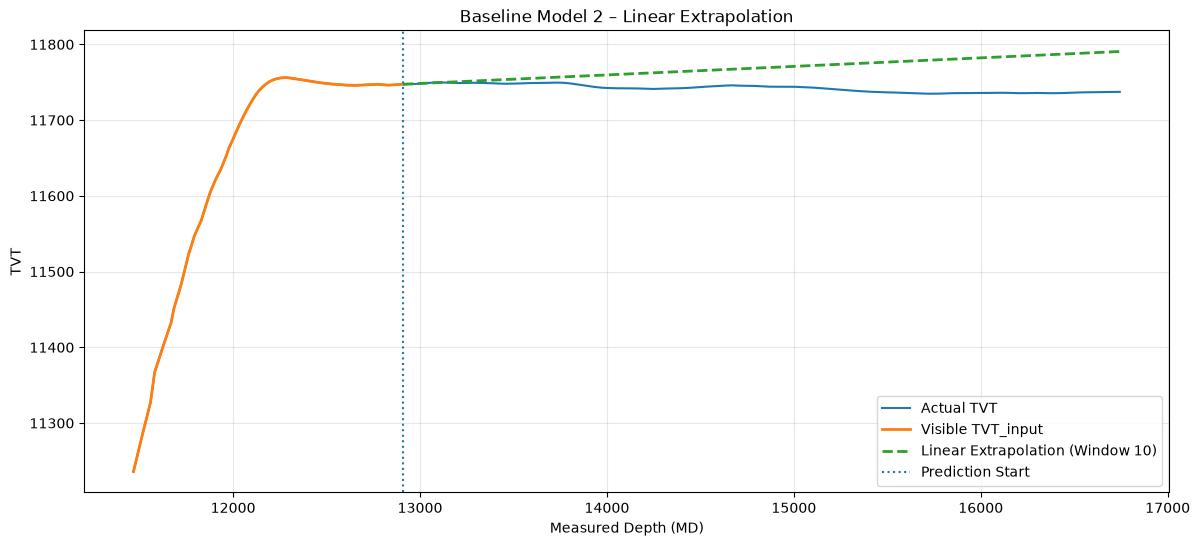

In [54]:
if best_sample_window is not None:
    best_sample_linear_result = (
        sample_linear_results[
            best_sample_window
        ]
    )

    sample_linear_full = np.full(
        len(sample_horizontal),
        np.nan
    )

    sample_linear_full[
        sample_prediction_mask.to_numpy()
    ] = best_sample_linear_result[
        "Predictions"
    ]

    plt.figure(figsize=(14, 6))

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT"],
        linewidth=1.5,
        label="Actual TVT"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT_input"],
        linewidth=2,
        label="Visible TVT_input"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_linear_full,
        linestyle="--",
        linewidth=2,
        label=(
            "Linear Extrapolation "
            f"(Window {best_sample_window})"
        )
    )

    plt.axvline(
        prediction_start_md,
        linestyle=":",
        label="Prediction Start"
    )

    plt.title(
        "Baseline Model 2 – Linear Extrapolation"
    )

    plt.xlabel("Measured Depth (MD)")
    plt.ylabel("TVT")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

#### 7.6 Compare Baseline 1 and Baseline 2

In [55]:
if best_sample_window is not None:
    best_linear_metrics = (
        calculate_regression_metrics(
            sample_actual_tvt,
            sample_linear_results[
                best_sample_window
            ]["Predictions"]
        )
    )
else:
    best_linear_metrics = {
        "MAE": np.nan,
        "RMSE": np.nan,
        "Bias": np.nan,
        "Evaluation_Rows": 0
    }

baseline_1_and_2_comparison = pd.DataFrame([
    {
        "Model": "Last Known TVT",
        **sample_last_known_metrics
    },
    {
        "Model": (
            f"Linear Extrapolation "
            f"{best_sample_window}"
        ),
        **best_linear_metrics
    }
])

display(
    baseline_1_and_2_comparison
    .sort_values("MAE")
)

,Model,MAE,RMSE,Bias,Evaluation_Rows
0,Last Known TVT,6.1350,7.4544,5.4456,3836
1,Linear Extrapolation 10,27.0882,32.1078,27.0723,3836


#### 7.7 Baseline 2 Observation

The linear model uses the recent TVT slope just before Prediction Start and extends that slope through the missing section.

On the sample well, all three windows had a positive slope (about 0.011 to 0.017). Window 10 was the best of the three, but it was still much weaker than Baseline 1:

- Window 10 MAE: 27.09
- Window 50 MAE: 37.48
- Window 100 MAE: 29.38

The comparison table shows Last Known TVT at MAE 6.14 versus Linear Extrapolation 10 at MAE 27.09.

The plot explains the gap. The green dashed line keeps climbing after Prediction Start, while the true TVT stays nearly flat and then drifts slightly downward. The recent upward trend did not continue, so the error grows with depth. For this well, a constant hold is safer than assuming the near-boundary slope continues.

### 8. Implement Baseline Model 3 – Z to TVT Linear Model

This baseline uses the horizontal-well `Z` coordinate to estimate TVT.

Because `Z` represents vertical position and TVT is also related to vertical depth, a linear relationship may exist between them.

The model learns the relationship between `Z` and the visible `TVT_input` values, then applies that relationship to the prediction section.

#### 8.1 Create the Z-Based Prediction Function

In [56]:
def predict_tvt_from_z(horizontal_data):
    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    model_result = fit_simple_linear_model(
        train_feature=(
            horizontal_data.loc[
                known_mask,
                "Z"
            ]
        ),
        train_target=(
            horizontal_data.loc[
                known_mask,
                "TVT_input"
            ]
        ),
        prediction_feature=(
            horizontal_data.loc[
                prediction_mask,
                "Z"
            ]
        )
    )

    if model_result is None:
        return None

    return {
        "Predictions": model_result[
            "Predictions"
        ],
        "Slope": model_result[
            "Slope"
        ],
        "Intercept": model_result[
            "Intercept"
        ],
        "Training_Rows": model_result[
            "Training_Rows"
        ]
    }

#### 8.2 Test the Z-Based Model

The Z-based model is first tested using the selected sample well.

The output shows the fitted slope, intercept, number of training rows, and number of generated predictions.

In [57]:
sample_z_result = predict_tvt_from_z(
    sample_horizontal
)

if sample_z_result is not None:
    print(
        "Z slope:",
        sample_z_result["Slope"]
    )

    print(
        "Z intercept:",
        sample_z_result["Intercept"]
    )

    print(
        "Training rows:",
        sample_z_result[
            "Training_Rows"
        ]
    )

    print(
        "Prediction rows:",
        len(
            sample_z_result[
                "Predictions"
            ]
        )
    )
else:
    print(
        "The Z-based model could not be fitted."
    )

Z slope: -1.0400984579797212
Z intercept: 1612.3992642410406
Training rows: 1442
Prediction rows: 3836


#### 8.3 Evaluate the Z-Based Model

The predicted TVT values are compared with the actual TVT values in the prediction section.

MAE, RMSE, and bias are calculated using the same evaluation function used for the previous baselines.

In [58]:
if sample_z_result is not None:
    sample_z_metrics = (
        calculate_regression_metrics(
            sample_actual_tvt,
            sample_z_result[
                "Predictions"
            ]
        )
    )
else:
    sample_z_metrics = {
        "MAE": np.nan,
        "RMSE": np.nan,
        "Bias": np.nan,
        "Evaluation_Rows": 0
    }

display(
    pd.Series(
        sample_z_metrics
    ).to_frame("Value")
)

,Value
MAE,58.2800
RMSE,64.6276
Bias,-58.2800
Evaluation_Rows,"3,836.0000"


#### 8.4 Calculate the Known-Section Z–TVT Correlation

The correlation measures the strength of the linear relationship between `Z` and visible `TVT_input`.

This helps explain whether the Z-based model is likely to work well for the selected well.

In [59]:
sample_known_z_tvt_data = (
    sample_horizontal.loc[
        sample_known_mask,
        ["Z", "TVT_input"]
    ]
    .dropna()
)

if (
    len(sample_known_z_tvt_data) >= 2
    and sample_known_z_tvt_data[
        "Z"
    ].nunique() >= 2
    and sample_known_z_tvt_data[
        "TVT_input"
    ].nunique() >= 2
):
    sample_known_z_tvt_correlation = (
        sample_known_z_tvt_data
        .corr()
        .iloc[0, 1]
    )
else:
    sample_known_z_tvt_correlation = np.nan

print(
    "Known-section Z-TVT correlation:",
    sample_known_z_tvt_correlation
)

Known-section Z-TVT correlation: -0.9991875179682903


#### 8.5 Visualize the Z-Based Prediction

The graph compares the actual TVT curve, visible `TVT_input`, and the Z-based prediction.

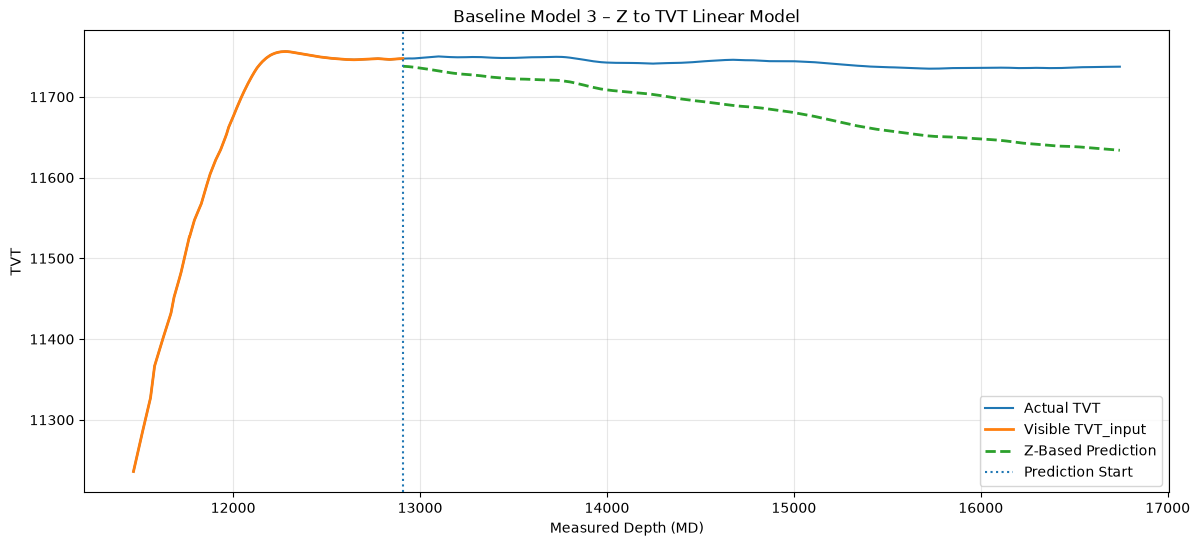

In [60]:
if sample_z_result is not None:
    sample_z_full = np.full(
        len(sample_horizontal),
        np.nan
    )

    sample_z_full[
        sample_prediction_mask.to_numpy()
    ] = sample_z_result[
        "Predictions"
    ]

    plt.figure(figsize=(14, 6))

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT"],
        linewidth=1.5,
        label="Actual TVT"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT_input"],
        linewidth=2,
        label="Visible TVT_input"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_z_full,
        linestyle="--",
        linewidth=2,
        label="Z-Based Prediction"
    )

    plt.axvline(
        prediction_start_md,
        linestyle=":",
        label="Prediction Start"
    )

    plt.title(
        "Baseline Model 3 – Z to TVT Linear Model"
    )

    plt.xlabel("Measured Depth (MD)")
    plt.ylabel("TVT")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

#### 8.6 Compare Baselines 1, 2, and 3

In [61]:
baseline_1_to_3_comparison = pd.DataFrame([
    {
        "Model": "Last Known TVT",
        **sample_last_known_metrics
    },
    {
        "Model": (
            f"Linear Extrapolation "
            f"{best_sample_window}"
        ),
        **best_linear_metrics
    },
    {
        "Model": "Z to TVT Linear Model",
        **sample_z_metrics
    }
])

display(
    baseline_1_to_3_comparison
    .sort_values("MAE")
)

,Model,MAE,RMSE,Bias,Evaluation_Rows
0,Last Known TVT,6.1350,7.4544,5.4456,3836
1,Linear Extrapolation 10,27.0882,32.1078,27.0723,3836
2,Z to TVT Linear Model,58.2800,64.6276,-58.2800,3836


#### 8.7 Baseline 3 Observation

The Z-to-TVT model fits a straight line between Z and the visible TVT values, then applies that line in the prediction section.

In the known section the Z–TVT link looks almost perfect, with a correlation of about -0.999. That suggests a strong relationship before Prediction Start. On the hidden section, however, performance is much weaker:

- MAE: 58.28
- RMSE: 64.63
- Bias: -58.28

Compared with the earlier baselines, this ranks third on the sample well (Last Known 6.14, Linear 27.09, Z model 58.28).

The plot shows the issue clearly. After Prediction Start the true TVT stays nearly flat, but the green Z-based prediction drifts steadily downward and ends well below the actual curve. A strong known-section correlation does not guarantee that the same Z–TVT relationship will hold later in the well. This baseline still needs to be checked across many wells before judging its overall value.

### 9. Implement Baseline Model 4 – Formation Marker Baseline

The horizontal-well dataset contains several formation-marker columns:

- `ANCC`
- `ASTNU`
- `ASTNL`
- `EGFDU`
- `EGFDL`
- `BUDA`

These columns may represent geological surfaces or formation boundaries.

This baseline tests whether one of these formation columns can help estimate TVT.

To avoid data leakage, the best formation column is selected using only the known `TVT_input` section.

#### 9.1 Split the Known Section

The known section is divided chronologically:

- The first 80% is used to fit the relationship.
- The final 20% is used to evaluate each formation column.

This allows the best formation column to be selected without using the hidden prediction-section TVT.

In [62]:
def split_known_section(
    horizontal_data,
    validation_fraction=0.20
):
    known_data = (
        horizontal_data.loc[
            horizontal_data[
                "TVT_input"
            ].notna()
        ]
        .copy()
    )

    if len(known_data) < 5:
        return None, None

    split_position = int(
        len(known_data)
        * (
            1 - validation_fraction
        )
    )

    split_position = max(
        2,
        min(
            split_position,
            len(known_data) - 1
        )
    )

    training_data = (
        known_data.iloc[
            :split_position
        ]
    )

    validation_data = (
        known_data.iloc[
            split_position:
        ]
    )

    return (
        training_data,
        validation_data
    )

#### 9.2 Evaluate Formation Columns

A separate linear relationship is fitted between each formation-marker column and `TVT_input`.

Each model is evaluated on the final 20% of the known section.

In [63]:
def evaluate_formation_columns(
    horizontal_data,
    formation_columns=FORMATION_COLUMNS,
    validation_fraction=0.20
):
    training_data, validation_data = (
        split_known_section(
            horizontal_data,
            validation_fraction
        )
    )

    if (
        training_data is None
        or validation_data is None
    ):
        return pd.DataFrame()

    available_columns = [
        column
        for column in formation_columns
        if column in horizontal_data.columns
    ]

    evaluation_rows = []

    for column in available_columns:
        training_subset = (
            training_data[
                [column, "TVT_input"]
            ]
            .dropna()
        )

        validation_subset = (
            validation_data[
                [column, "TVT_input"]
            ]
            .dropna()
        )

        if (
            len(training_subset) < 2
            or training_subset[
                column
            ].nunique() < 2
            or len(validation_subset) == 0
        ):
            evaluation_rows.append({
                "Formation_Column": column,
                "Validation_MAE": np.nan,
                "Validation_RMSE": np.nan,
                "Validation_Bias": np.nan,
                "Slope": np.nan,
                "Intercept": np.nan,
                "Training_Rows": len(
                    training_subset
                ),
                "Validation_Rows": len(
                    validation_subset
                )
            })

            continue

        slope, intercept = np.polyfit(
            training_subset[column],
            training_subset[
                "TVT_input"
            ],
            1
        )

        validation_predictions = (
            slope
            * validation_subset[column]
            + intercept
        )

        metrics = (
            calculate_regression_metrics(
                validation_subset[
                    "TVT_input"
                ],
                validation_predictions
            )
        )

        evaluation_rows.append({
            "Formation_Column": column,
            "Validation_MAE": (
                metrics["MAE"]
            ),
            "Validation_RMSE": (
                metrics["RMSE"]
            ),
            "Validation_Bias": (
                metrics["Bias"]
            ),
            "Slope": slope,
            "Intercept": intercept,
            "Training_Rows": len(
                training_subset
            ),
            "Validation_Rows": (
                metrics[
                    "Evaluation_Rows"
                ]
            )
        })

    return pd.DataFrame(
        evaluation_rows
    )

#### 9.3 Test the Formation Columns

In [64]:
sample_formation_validation = (
    evaluate_formation_columns(
        sample_horizontal
    )
)

display(
    sample_formation_validation
    .sort_values(
        "Validation_MAE"
    )
)

,Formation_Column,Validation_MAE,Validation_RMSE,Validation_Bias,Slope,Intercept,Training_Rows,Validation_Rows
3,EGFDU,87.7615,91.3607,87.7615,15.7934,"164,058.1009",1153,289
1,ASTNU,87.7615,91.3607,87.7615,15.7934,"162,460.9097",1153,289
5,BUDA,87.7615,91.3607,87.7615,15.7934,"166,827.6395",1153,289
0,ANCC,87.7615,91.3607,87.7615,15.7934,"159,712.0606",1153,289
2,ASTNL,87.7615,91.3607,87.7615,15.7934,"162,899.6517",1153,289
4,EGFDL,87.7615,91.3607,87.7615,15.7934,"164,610.3977",1153,289


#### 9.4 Create the Best Formation Prediction Function

The best formation column is selected using known-section validation MAE.

After selecting the column, the model is fitted again using the full known section and applied to the prediction section.

In [65]:
def predict_from_best_formation(
    horizontal_data,
    formation_columns=FORMATION_COLUMNS,
    validation_fraction=0.20
):
    formation_evaluation = (
        evaluate_formation_columns(
            horizontal_data,
            formation_columns,
            validation_fraction
        )
    )

    if formation_evaluation.empty:
        return None

    valid_evaluations = (
        formation_evaluation
        .dropna(
            subset=[
                "Validation_MAE"
            ]
        )
        .sort_values(
            "Validation_MAE"
        )
    )

    if valid_evaluations.empty:
        return None

    best_column = (
        valid_evaluations
        .iloc[0][
            "Formation_Column"
        ]
    )

    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    training_subset = (
        horizontal_data.loc[
            known_mask,
            [
                best_column,
                "TVT_input"
            ]
        ]
        .dropna()
    )

    if (
        len(training_subset) < 2
        or training_subset[
            best_column
        ].nunique() < 2
    ):
        return None

    slope, intercept = np.polyfit(
        training_subset[
            best_column
        ],
        training_subset[
            "TVT_input"
        ],
        1
    )

    prediction_feature = (
        horizontal_data.loc[
            prediction_mask,
            best_column
        ]
    )

    predictions = (
        slope
        * prediction_feature
        + intercept
    )

    predictions = predictions.astype(
        float
    )

    if predictions.isna().any():
        last_known_tvt = (
            horizontal_data.loc[
                known_mask,
                "TVT_input"
            ]
            .dropna()
            .iloc[-1]
        )

        predictions = (
            predictions.fillna(
                last_known_tvt
            )
        )

    best_validation_row = (
        valid_evaluations.iloc[0]
    )

    return {
        "Predictions": (
            predictions.to_numpy()
        ),
        "Best_Formation_Column": (
            best_column
        ),
        "Validation_MAE": (
            best_validation_row[
                "Validation_MAE"
            ]
        ),
        "Validation_RMSE": (
            best_validation_row[
                "Validation_RMSE"
            ]
        ),
        "Slope": slope,
        "Intercept": intercept,
        "Training_Rows": len(
            training_subset
        )
    }

#### 9.5 Test the Formation Baseline

In [66]:
sample_formation_result = (
    predict_from_best_formation(
        sample_horizontal
    )
)

if sample_formation_result is not None:
    print(
        "Best formation column:",
        sample_formation_result[
            "Best_Formation_Column"
        ]
    )

    print(
        "Known-section validation MAE:",
        sample_formation_result[
            "Validation_MAE"
        ]
    )

    print(
        "Known-section validation RMSE:",
        sample_formation_result[
            "Validation_RMSE"
        ]
    )

    print(
        "Final slope:",
        sample_formation_result[
            "Slope"
        ]
    )

    print(
        "Prediction rows:",
        len(
            sample_formation_result[
                "Predictions"
            ]
        )
    )
else:
    print(
        "No valid formation baseline "
        "could be created."
    )

Best formation column: EGFDU
Known-section validation MAE: 87.76149373348777
Known-section validation RMSE: 91.36071443367626
Final slope: 12.915261633141723
Prediction rows: 3836


#### 9.6 Evaluate the Formation Baseline

The final formation-based predictions are compared with the actual TVT values in the prediction section.

In [67]:
if sample_formation_result is not None:
    sample_formation_metrics = (
        calculate_regression_metrics(
            sample_actual_tvt,
            sample_formation_result[
                "Predictions"
            ]
        )
    )
else:
    sample_formation_metrics = {
        "MAE": np.nan,
        "RMSE": np.nan,
        "Bias": np.nan,
        "Evaluation_Rows": 0
    }

display(
    pd.Series(
        sample_formation_metrics
    ).to_frame("Value")
)

,Value
MAE,675.6698
RMSE,760.5518
Bias,675.6698
Evaluation_Rows,"3,836.0000"


#### 9.7 Visualize the Formation Prediction

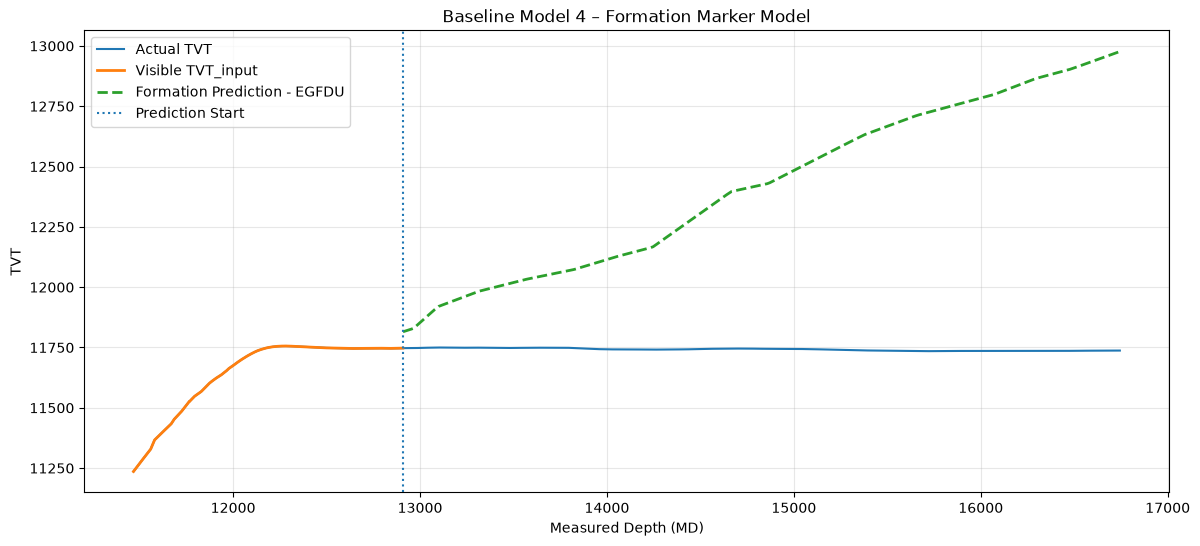

In [68]:
if sample_formation_result is not None:
    sample_formation_full = np.full(
        len(sample_horizontal),
        np.nan
    )

    sample_formation_full[
        sample_prediction_mask.to_numpy()
    ] = sample_formation_result[
        "Predictions"
    ]

    plt.figure(figsize=(14, 6))

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT"],
        linewidth=1.5,
        label="Actual TVT"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_horizontal["TVT_input"],
        linewidth=2,
        label="Visible TVT_input"
    )

    plt.plot(
        sample_horizontal["MD"],
        sample_formation_full,
        linestyle="--",
        linewidth=2,
        label=(
            "Formation Prediction - "
            + sample_formation_result[
                "Best_Formation_Column"
            ]
        )
    )

    plt.axvline(
        prediction_start_md,
        linestyle=":",
        label="Prediction Start"
    )

    plt.title(
        "Baseline Model 4 – Formation Marker Model"
    )

    plt.xlabel("Measured Depth (MD)")
    plt.ylabel("TVT")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

#### 9.8 Compare All Four Baselines

In [69]:
baseline_1_to_4_comparison = (
    pd.DataFrame([
        {
            "Model": "Last Known TVT",
            **sample_last_known_metrics
        },
        {
            "Model": (
                f"Linear Extrapolation "
                f"{best_sample_window}"
            ),
            **best_linear_metrics
        },
        {
            "Model": (
                "Z to TVT Linear Model"
            ),
            **sample_z_metrics
        },
        {
            "Model": (
                "Formation Marker Baseline"
            ),
            **sample_formation_metrics
        }
    ])
)

display(
    baseline_1_to_4_comparison
    .sort_values("MAE")
)

,Model,MAE,RMSE,Bias,Evaluation_Rows
0,Last Known TVT,6.1350,7.4544,5.4456,3836
1,Linear Extrapolation 10,27.0882,32.1078,27.0723,3836
2,Z to TVT Linear Model,58.2800,64.6276,-58.2800,3836
3,Formation Marker Baseline,675.6698,760.5518,675.6698,3836


#### 9.9 Baseline 4 Observation

The Formation Marker baseline chooses the formation column that best predicts the final part of the known TVT section, then uses that column to predict the missing section.

On the sample well, every formation column gave the same known-section validation MAE of about 87.76. EGFDU was selected as the best column. Once that relationship was applied to the true prediction section, the scores collapsed:

- MAE: 675.67
- RMSE: 760.55
- Bias: +675.67

That makes Formation Marker by far the weakest of the four baselines on this well (Last Known 6.14, Linear 27.09, Z model 58.28, Formation 675.67).

The plot matches those numbers. After Prediction Start the green EGFDU prediction jumps upward and keeps rising toward about 13,000, while the true TVT stays near 11,750. A formation link that looked usable in the known section did not transfer into the prediction section here. Different wells may pick different formation columns, and some wells may not support a reliable formation-based prediction at all.

### 10. Evaluate All Baselines Across All Training Wells

The four baseline methods are now evaluated across every training well pair.

For each well, predictions are created only for rows where `TVT_input` is missing. The complete training `TVT` values are used only for calculating evaluation metrics.

This dataset-wide evaluation helps identify which baseline performs most consistently across different wells.

#### 10.1 Create a Single-Well Evaluation Function

In [70]:
def evaluate_all_baselines_for_well(well_id):
    horizontal_data = pd.read_csv(
        horizontal_map[well_id]
    )

    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    if known_mask.sum() == 0:
        raise ValueError(
            "No known TVT_input rows."
        )

    if prediction_mask.sum() == 0:
        raise ValueError(
            "No prediction rows."
        )

    actual_tvt = (
        horizontal_data.loc[
            prediction_mask,
            "TVT"
        ]
        .to_numpy()
    )

    result_rows = []

    # Baseline 1 – Last Known TVT
    last_known_result = (
        predict_last_known_tvt(
            horizontal_data
        )
    )

    last_known_metrics = (
        calculate_regression_metrics(
            actual_tvt,
            last_known_result[
                "Predictions"
            ]
        )
    )

    result_rows.append({
        "Well_ID": well_id,
        "Model": "Last Known TVT",
        "Parameter": np.nan,
        **last_known_metrics
    })

    # Baseline 2 – Linear Extrapolation
    for window in LINEAR_WINDOWS:
        linear_result = (
            predict_linear_extrapolation(
                horizontal_data,
                window=window
            )
        )

        if linear_result is None:
            linear_metrics = {
                "MAE": np.nan,
                "RMSE": np.nan,
                "Bias": np.nan,
                "Evaluation_Rows": 0
            }
        else:
            linear_metrics = (
                calculate_regression_metrics(
                    actual_tvt,
                    linear_result[
                        "Predictions"
                    ]
                )
            )

        result_rows.append({
            "Well_ID": well_id,
            "Model": (
                f"Linear Extrapolation {window}"
            ),
            "Parameter": window,
            **linear_metrics
        })

    # Baseline 3 – Z to TVT
    z_result = predict_tvt_from_z(
        horizontal_data
    )

    if z_result is None:
        z_metrics = {
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "Evaluation_Rows": 0
        }
    else:
        z_metrics = (
            calculate_regression_metrics(
                actual_tvt,
                z_result[
                    "Predictions"
                ]
            )
        )

    result_rows.append({
        "Well_ID": well_id,
        "Model": "Z to TVT Linear Model",
        "Parameter": np.nan,
        **z_metrics
    })

    # Baseline 4 – Formation Marker
    formation_result = (
        predict_from_best_formation(
            horizontal_data
        )
    )

    if formation_result is None:
        formation_metrics = {
            "MAE": np.nan,
            "RMSE": np.nan,
            "Bias": np.nan,
            "Evaluation_Rows": 0
        }

        best_formation_column = None
    else:
        formation_metrics = (
            calculate_regression_metrics(
                actual_tvt,
                formation_result[
                    "Predictions"
                ]
            )
        )

        best_formation_column = (
            formation_result[
                "Best_Formation_Column"
            ]
        )

    result_rows.append({
        "Well_ID": well_id,
        "Model": (
            "Formation Marker Baseline"
        ),
        "Parameter": (
            best_formation_column
        ),
        **formation_metrics
    })

    return result_rows

#### 10.2 Test the Evaluation Function

In [71]:
sample_all_baseline_results = (
    evaluate_all_baselines_for_well(
        sample_id
    )
)

sample_all_baseline_results_df = (
    pd.DataFrame(
        sample_all_baseline_results
    )
)

display(
    sample_all_baseline_results_df
    .sort_values("MAE")
)

,Well_ID,Model,Parameter,MAE,RMSE,Bias,Evaluation_Rows
0,000d7d20_,Last Known TVT,NaN,6.1350,7.4544,5.4456,3836
1,000d7d20_,Linear Extrapolation 10,10,27.0882,32.1078,27.0723,3836
3,000d7d20_,Linear Extrapolation 100,100,29.3843,34.7624,29.3775,3836
2,000d7d20_,Linear Extrapolation 50,50,37.4755,44.0944,37.4755,3836
4,000d7d20_,Z to TVT Linear Model,NaN,58.2800,64.6276,-58.2800,3836
5,000d7d20_,Formation Marker Baseline,EGFDU,675.6698,760.5518,675.6698,3836


#### 10.3 Process All Training Wells

Each baseline is applied to every complete training well pair.

Errors are captured so that one problematic well does not stop the full evaluation process.

In [72]:
all_baseline_results = []
failed_baseline_wells = []

for index, well_id in enumerate(
    complete_ids,
    start=1
):
    try:
        well_results = (
            evaluate_all_baselines_for_well(
                well_id
            )
        )

        all_baseline_results.extend(
            well_results
        )

    except Exception as error:
        failed_baseline_wells.append({
            "Well_ID": well_id,
            "Error": str(error)
        })

    if index % 100 == 0:
        print(
            f"Processed {index} wells"
        )

Processed 100 wells
Processed 200 wells
Processed 300 wells
Processed 400 wells
Processed 500 wells
Processed 600 wells
Processed 700 wells


#### 10.4 Create the Results DataFrame

In [73]:
baseline_results = pd.DataFrame(
    all_baseline_results
)

failed_baseline_wells_df = (
    pd.DataFrame(
        failed_baseline_wells
    )
)

print(
    "Baseline result rows:",
    len(baseline_results)
)

print(
    "Unique wells evaluated:",
    baseline_results[
        "Well_ID"
    ].nunique()
)

print(
    "Failed wells:",
    len(
        failed_baseline_wells_df
    )
)

display(
    baseline_results.head(10)
)

display(
    failed_baseline_wells_df
)

Baseline result rows: 4638
Unique wells evaluated: 773
Failed wells: 0


,Well_ID,Model,Parameter,MAE,RMSE,Bias,Evaluation_Rows
0,000d7d20_,Last Known TVT,NaN,6.1350,7.4544,5.4456,3836
1,000d7d20_,Linear Extrapolation 10,10,27.0882,32.1078,27.0723,3836
2,000d7d20_,Linear Extrapolation 50,50,37.4755,44.0944,37.4755,3836
3,000d7d20_,Linear Extrapolation 100,100,29.3843,34.7624,29.3775,3836
4,000d7d20_,Z to TVT Linear Model,NaN,58.2800,64.6276,-58.2800,3836
5,000d7d20_,Formation Marker Baseline,EGFDU,675.6698,760.5518,675.6698,3836
6,00bbac68_,Last Known TVT,NaN,12.1043,15.2631,2.5219,6014
7,00bbac68_,Linear Extrapolation 10,10,53.8339,68.0760,53.7405,6014
8,00bbac68_,Linear Extrapolation 50,50,41.9948,54.6432,41.8237,6014
9,00bbac68_,Linear Extrapolation 100,100,25.9515,36.4757,25.3485,6014


""


#### 10.5 Validate the Result Counts

In [74]:
model_result_counts = (
    baseline_results[
        "Model"
    ]
    .value_counts()
)

display(
    model_result_counts
    .to_frame(
        "Result_Count"
    )
)

,Result_Count
Model,
Last Known TVT,773
Linear Extrapolation 10,773
Linear Extrapolation 50,773
Linear Extrapolation 100,773
Z to TVT Linear Model,773
Formation Marker Baseline,773


#### 10.6 Check Missing Evaluation Results

In [75]:
missing_metric_summary = (
    baseline_results
    .groupby("Model")
    .agg(
        Total_Results=(
            "Well_ID",
            "size"
        ),
        Valid_MAE=(
            "MAE",
            "count"
        ),
        Missing_MAE=(
            "MAE",
            lambda series: (
                series.isna().sum()
            )
        ),
        Valid_RMSE=(
            "RMSE",
            "count"
        )
    )
    .sort_values(
        "Valid_MAE",
        ascending=False
    )
)

display(
    missing_metric_summary
)

,Total_Results,Valid_MAE,Missing_MAE,Valid_RMSE
Model,,,,
Formation Marker Baseline,773,773,0,773
Last Known TVT,773,773,0,773
Linear Extrapolation 10,773,773,0,773
Linear Extrapolation 100,773,773,0,773
Linear Extrapolation 50,773,773,0,773
Z to TVT Linear Model,773,773,0,773


#### 10.7 Basic Dataset-Wide Result Preview

In [76]:
display(
    baseline_results[
        [
            "Model",
            "MAE",
            "RMSE",
            "Bias",
            "Evaluation_Rows"
        ]
    ]
    .groupby("Model")
    .describe()
)

MAE                                     \
                             count     mean      std     min      25%   
Model                                                                   
Formation Marker Baseline 773.0000 903.6561 592.5908 46.6061 527.8574   
Last Known TVT            773.0000  10.9323   8.1367  0.8203   5.8304   
Linear Extrapolation 10   773.0000  49.3559  69.1215  1.5316  14.3407   
Linear Extrapolation 100  773.0000  51.2812  78.3628  0.8287  13.6309   
Linear Extrapolation 50   773.0000  51.6731  75.0689  1.6234  13.9070   
Z to TVT Linear Model     773.0000  99.6183  37.1761 11.8816  74.5198   

                                                             RMSE             \
                               50%        75%        max    count       mean   
Model                                                                          
Formation Marker Baseline 801.0324 1,138.5843 5,294.6203 773.0000 1,017.9323   
Last Known TVT              8.7286    13.2305    65.9312 773.0000    12.8125   
Linear Extrapolation 10    30.5816    64.5314 1,122.4804 773.0000    58.1355   
Linear Extrapolation 100   32.1667    68.0934 1,232.3245 773.0000    60.1914   
Linear Extrapolation 50    32.4676    68.8330 1,194.1292 773.0000    60.6829   
Z to TVT Linear Model      96.2368   120.1388   258.1308 773.0000   110.8777   

                                                                         \
                               std     min      25%      50%        75%   
Model                                                                     
Formation Marker Baseline 676.5793 56.1482 598.1259 893.8264 1,267.6848   
Last Known TVT              8.8995  1.1159   7.1007  10.6651    15.8113   
Linear Extrapolation 10    80.4469  2.1050  17.1678  37.2149    75.3381   
Linear Extrapolation 100   91.0576  1.1543  16.5397  36.7085    80.7835   
Linear Extrapolation 50    87.2597  1.9515  16.6444  37.9880    79.4618   
Z to TVT Linear Model      41.3900 13.4981  82.7242 107.1353   133.1722   

                                         Bias                                \
                                 max    count     mean      std         min   
Model                                                                         
Formation Marker Baseline 6,154.6013 773.0000 727.7231 798.1151 -3,227.4658   
Last Known TVT               70.6394 773.0000  -1.4232  12.6984    -65.9312   
Linear Extrapolation 10   1,309.7129 773.0000   2.2783  84.7887   -315.4662   
Linear Extrapolation 100  1,436.5204 773.0000   3.2507  93.5100   -328.9654   
Linear Extrapolation 50   1,392.4261 773.0000   3.2135  90.9796   -321.2112   
Z to TVT Linear Model       291.5363 773.0000 -22.9182 103.8788   -258.1308   

                                                                    \
                                25%      50%        75%        max   
Model                                                                
Formation Marker Baseline  370.5224 753.4534 1,112.7912 5,294.6203   
Last Known TVT              -8.1270  -0.9429     5.2693    46.5001   
Linear Extrapolation 10    -29.8556   0.1709    31.3874 1,122.4804   
Linear Extrapolation 100   -29.5735  -0.3600    33.0762 1,232.3245   
Linear Extrapolation 50    -30.3131   0.8518    33.4479 1,194.1292   
Z to TVT Linear Model     -109.8911 -64.7525    80.8960   201.6247   

                          Evaluation_Rows                                 \
                                    count       mean        std      min   
Model                                                                      
Formation Marker Baseline        773.0000 4,895.1992 1,301.1784 407.0000   
Last Known TVT                   773.0000 4,895.1992 1,301.1784 407.0000   
Linear Extrapolation 10          773.0000 4,895.1992 1,301.1784 407.0000   
Linear Extrapolation 100         773.0000 4,895.1992 1,301.1784 407.0000   
Linear Extrapolation 50          773.0000 4,895.1992 1,301.1784 407.0000   
Z to TVT Linear Model    

#### 10.8 Dataset-Wide Evaluation Check

The baseline evaluation produced one result per model for each training well.

The next section will compare the models using overall MAE, RMSE, median well error, average bias, and the number of successful wells.

### 11. Compare Baseline Performance

The baseline models are compared using both well-level and row-level performance.

Well-level statistics treat every well equally, while row-level statistics give more influence to wells with more prediction rows.

The comparison includes:

- Mean MAE across wells
- Median MAE across wells
- Mean RMSE across wells
- Median RMSE across wells
- Mean bias
- Number of successful wells
- Overall weighted MAE
- Overall weighted RMSE

#### 11.1 Create the Well-Level Comparison Table

In [77]:
well_level_comparison = (
    baseline_results
    .groupby("Model")
    .agg(
        Successful_Wells=(
            "MAE",
            "count"
        ),
        Mean_Well_MAE=(
            "MAE",
            "mean"
        ),
        Median_Well_MAE=(
            "MAE",
            "median"
        ),
        Mean_Well_RMSE=(
            "RMSE",
            "mean"
        ),
        Median_Well_RMSE=(
            "RMSE",
            "median"
        ),
        Mean_Bias=(
            "Bias",
            "mean"
        ),
        Median_Bias=(
            "Bias",
            "median"
        )
    )
    .sort_values(
        "Median_Well_MAE"
    )
)

display(
    well_level_comparison
)

,Successful_Wells,Mean_Well_MAE,Median_Well_MAE,Mean_Well_RMSE,Median_Well_RMSE,Mean_Bias,Median_Bias
Model,,,,,,,
Last Known TVT,773,10.9323,8.7286,12.8125,10.6651,-1.4232,-0.9429
Linear Extrapolation 10,773,49.3559,30.5816,58.1355,37.2149,2.2783,0.1709
Linear Extrapolation 100,773,51.2812,32.1667,60.1914,36.7085,3.2507,-0.3600
Linear Extrapolation 50,773,51.6731,32.4676,60.6829,37.9880,3.2135,0.8518
Z to TVT Linear Model,773,99.6183,96.2368,110.8777,107.1353,-22.9182,-64.7525
Formation Marker Baseline,773,903.6561,801.0324,"1,017.9323",893.8264,727.7231,753.4534


#### 11.2 Calculate Weighted Overall Metrics

The previous table treats each well equally.

The following calculation weights each well by its number of prediction rows, giving an overall dataset-level estimate.

In [78]:
def calculate_weighted_model_metrics(
    model_results
):
    valid_results = (
        model_results
        .dropna(
            subset=[
                "MAE",
                "RMSE",
                "Evaluation_Rows"
            ]
        )
        .copy()
    )

    valid_results = valid_results.loc[
        valid_results[
            "Evaluation_Rows"
        ] > 0
    ]

    if valid_results.empty:
        return pd.Series({
            "Weighted_MAE": np.nan,
            "Weighted_RMSE": np.nan,
            "Total_Evaluation_Rows": 0
        })

    total_rows = (
        valid_results[
            "Evaluation_Rows"
        ].sum()
    )

    weighted_mae = np.average(
        valid_results["MAE"],
        weights=valid_results[
            "Evaluation_Rows"
        ]
    )

    weighted_mse = np.average(
        valid_results["RMSE"] ** 2,
        weights=valid_results[
            "Evaluation_Rows"
        ]
    )

    weighted_rmse = np.sqrt(
        weighted_mse
    )

    return pd.Series({
        "Weighted_MAE": weighted_mae,
        "Weighted_RMSE": weighted_rmse,
        "Total_Evaluation_Rows": total_rows
    })

In [79]:
weighted_comparison = (
    baseline_results
    .groupby(
        "Model",
        group_keys=False
    )
    .apply(
        calculate_weighted_model_metrics
    )
    .sort_values(
        "Weighted_MAE"
    )
)

display(
    weighted_comparison
)

,Weighted_MAE,Weighted_RMSE,Total_Evaluation_Rows
Model,,,
Last Known TVT,11.1965,15.9099,"3,783,989.0000"
Linear Extrapolation 10,53.6928,105.6554,"3,783,989.0000"
Linear Extrapolation 100,56.1481,117.2219,"3,783,989.0000"
Linear Extrapolation 50,56.4415,113.6347,"3,783,989.0000"
Z to TVT Linear Model,104.7695,124.2319,"3,783,989.0000"
Formation Marker Baseline,964.8924,"1,306.3638","3,783,989.0000"


#### 11.3 Combine Well-Level and Weighted Results

In [80]:
baseline_comparison = (
    well_level_comparison
    .join(
        weighted_comparison,
        how="left"
    )
    .reset_index()
    .sort_values(
        "Median_Well_MAE"
    )
)

display(
    baseline_comparison
)

,Model,Successful_Wells,Mean_Well_MAE,Median_Well_MAE,Mean_Well_RMSE,Median_Well_RMSE,Mean_Bias,Median_Bias,Weighted_MAE,Weighted_RMSE,Total_Evaluation_Rows
0,Last Known TVT,773,10.9323,8.7286,12.8125,10.6651,-1.4232,-0.9429,11.1965,15.9099,"3,783,989.0000"
1,Linear Extrapolation 10,773,49.3559,30.5816,58.1355,37.2149,2.2783,0.1709,53.6928,105.6554,"3,783,989.0000"
2,Linear Extrapolation 100,773,51.2812,32.1667,60.1914,36.7085,3.2507,-0.3600,56.1481,117.2219,"3,783,989.0000"
3,Linear Extrapolation 50,773,51.6731,32.4676,60.6829,37.9880,3.2135,0.8518,56.4415,113.6347,"3,783,989.0000"
4,Z to TVT Linear Model,773,99.6183,96.2368,110.8777,107.1353,-22.9182,-64.7525,104.7695,124.2319,"3,783,989.0000"
5,Formation Marker Baseline,773,903.6561,801.0324,"1,017.9323",893.8264,727.7231,753.4534,964.8924,"1,306.3638","3,783,989.0000"


#### 11.4 Rank the Baseline Models

In [81]:
baseline_comparison[
    "MAE_Rank"
] = (
    baseline_comparison[
        "Median_Well_MAE"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

baseline_comparison[
    "RMSE_Rank"
] = (
    baseline_comparison[
        "Median_Well_RMSE"
    ]
    .rank(
        method="min"
    )
    .astype(int)
)

baseline_comparison[
    "Overall_Rank"
] = (
    baseline_comparison[
        [
            "MAE_Rank",
            "RMSE_Rank"
        ]
    ]
    .mean(axis=1)
)

baseline_comparison = (
    baseline_comparison
    .sort_values(
        [
            "Overall_Rank",
            "Median_Well_MAE"
        ]
    )
)

display(
    baseline_comparison
)

,Model,Successful_Wells,Mean_Well_MAE,Median_Well_MAE,Mean_Well_RMSE,Median_Well_RMSE,Mean_Bias,Median_Bias,Weighted_MAE,Weighted_RMSE,Total_Evaluation_Rows,MAE_Rank,RMSE_Rank,Overall_Rank
0,Last Known TVT,773,10.9323,8.7286,12.8125,10.6651,-1.4232,-0.9429,11.1965,15.9099,"3,783,989.0000",1,1,1.0000
1,Linear Extrapolation 10,773,49.3559,30.5816,58.1355,37.2149,2.2783,0.1709,53.6928,105.6554,"3,783,989.0000",2,3,2.5000
2,Linear Extrapolation 100,773,51.2812,32.1667,60.1914,36.7085,3.2507,-0.3600,56.1481,117.2219,"3,783,989.0000",3,2,2.5000
3,Linear Extrapolation 50,773,51.6731,32.4676,60.6829,37.9880,3.2135,0.8518,56.4415,113.6347,"3,783,989.0000",4,4,4.0000
4,Z to TVT Linear Model,773,99.6183,96.2368,110.8777,107.1353,-22.9182,-64.7525,104.7695,124.2319,"3,783,989.0000",5,5,5.0000
5,Formation Marker Baseline,773,903.6561,801.0324,"1,017.9323",893.8264,727.7231,753.4534,964.8924,"1,306.3638","3,783,989.0000",6,6,6.0000


#### 11.5 Identify the Best Baseline

In [82]:
best_baseline_row = (
    baseline_comparison
    .iloc[0]
)

best_baseline_model = (
    best_baseline_row[
        "Model"
    ]
)

print(
    "Best baseline model:",
    best_baseline_model
)

print(
    "Median well MAE:",
    best_baseline_row[
        "Median_Well_MAE"
    ]
)

print(
    "Median well RMSE:",
    best_baseline_row[
        "Median_Well_RMSE"
    ]
)

print(
    "Weighted MAE:",
    best_baseline_row[
        "Weighted_MAE"
    ]
)

print(
    "Successful wells:",
    int(
        best_baseline_row[
            "Successful_Wells"
        ]
    )
)

Best baseline model: Last Known TVT
Median well MAE: 8.728593245227767
Median well RMSE: 10.665140786694133
Weighted MAE: 11.196479701711613
Successful wells: 773


#### 11.6 Visualize Median Well MAE

The chart compares the typical prediction error of each baseline model.

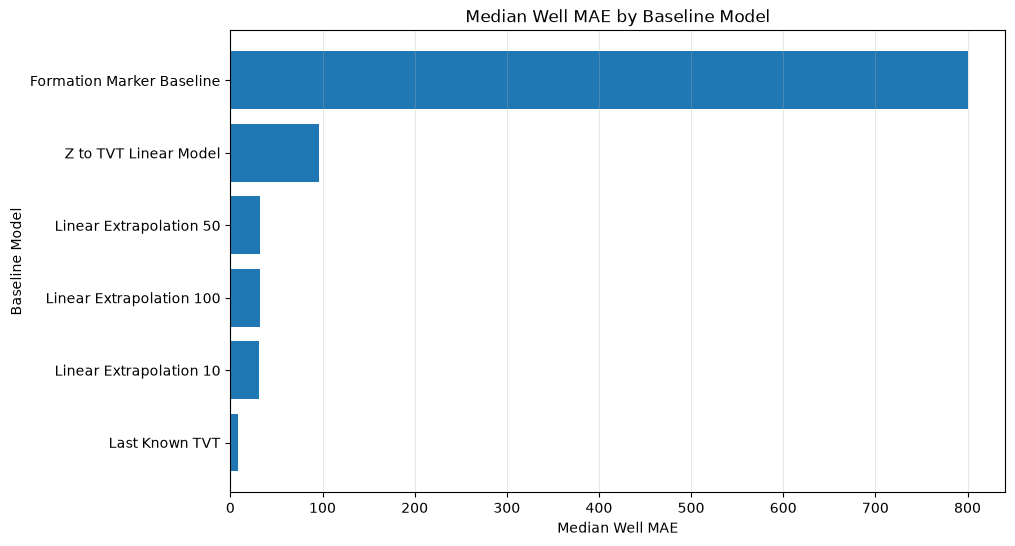

In [83]:
mae_plot_data = (
    baseline_comparison
    .sort_values(
        "Median_Well_MAE",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    mae_plot_data["Model"],
    mae_plot_data[
        "Median_Well_MAE"
    ]
)

plt.title(
    "Median Well MAE by Baseline Model"
)

plt.xlabel("Median Well MAE")
plt.ylabel("Baseline Model")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

#### 11.7 Plot Median RMSE by Model

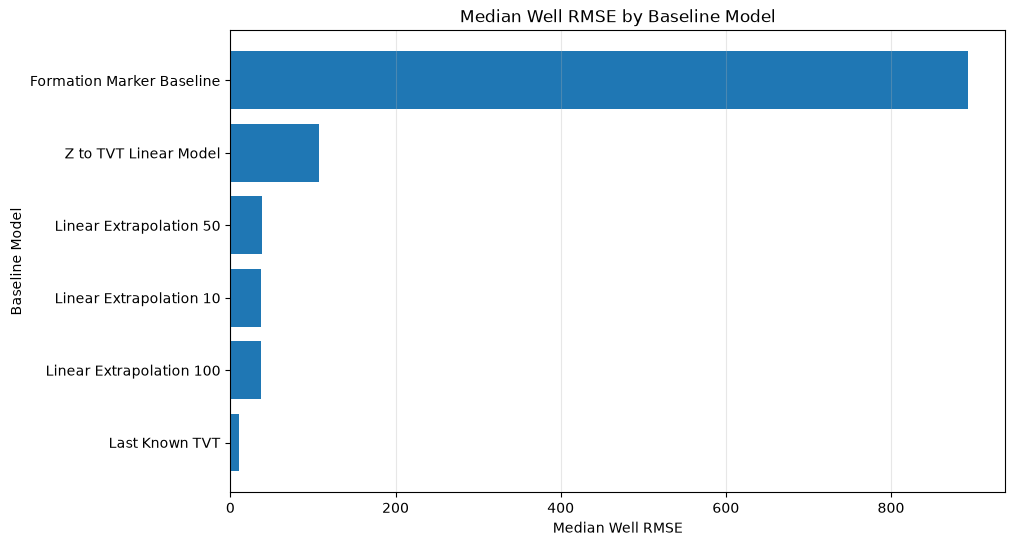

In [84]:
rmse_plot_data = (
    baseline_comparison
    .sort_values(
        "Median_Well_RMSE",
        ascending=True
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    rmse_plot_data["Model"],
    rmse_plot_data[
        "Median_Well_RMSE"
    ]
)

plt.title(
    "Median Well RMSE by Baseline Model"
)

plt.xlabel("Median Well RMSE")
plt.ylabel("Baseline Model")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

#### 11.8 Compare MAE Distributions

The box plot shows how consistent each baseline is across different wells.

A compact box indicates stable performance, while a wide box or many outliers indicates inconsistent performance.

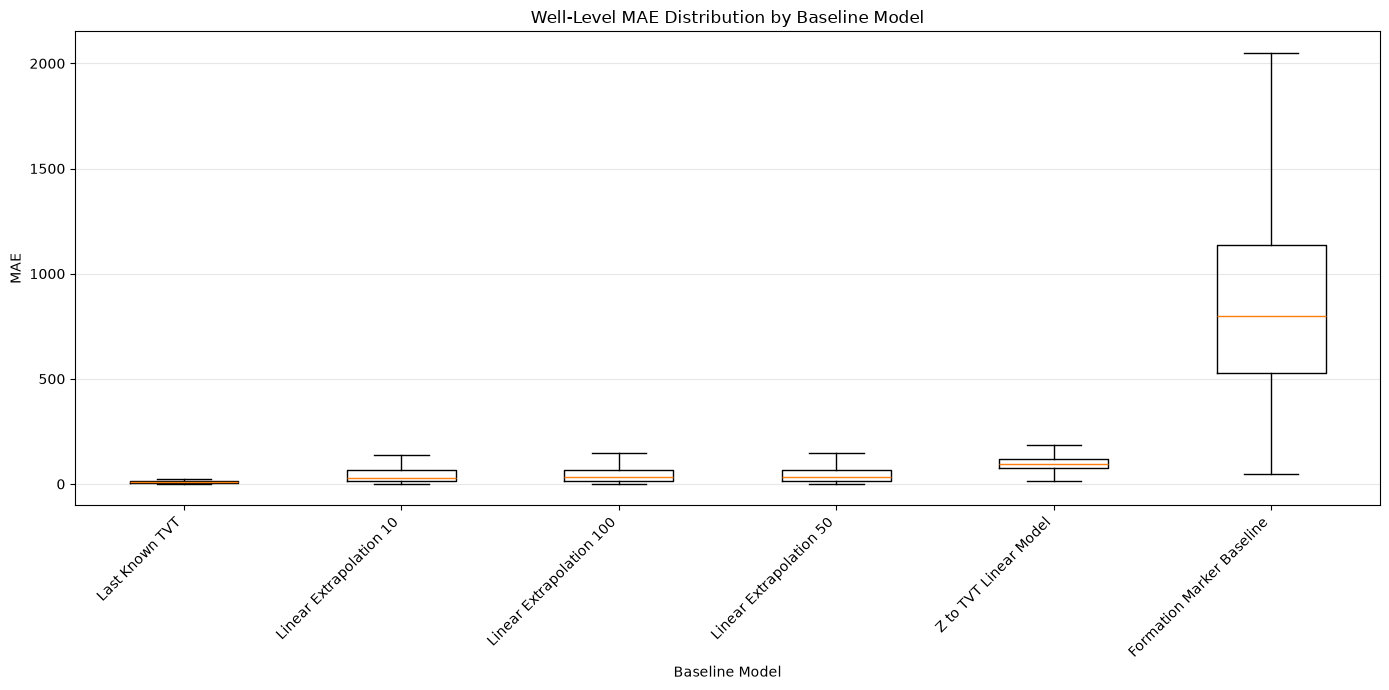

In [86]:
model_order = (
    baseline_comparison[
        "Model"
    ]
    .tolist()
)

mae_distribution_data = [
    baseline_results.loc[
        baseline_results[
            "Model"
        ] == model,
        "MAE"
    ]
    .dropna()
    .to_numpy()
    for model in model_order
]

plt.figure(figsize=(14, 7))

plt.boxplot(
    mae_distribution_data,
    tick_labels=model_order,
    showfliers=False
)

plt.title(
    "Well-Level MAE Distribution by Baseline Model"
)

plt.xlabel("Baseline Model")
plt.ylabel("MAE")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

#### 11.9 Compare Bias Across Models

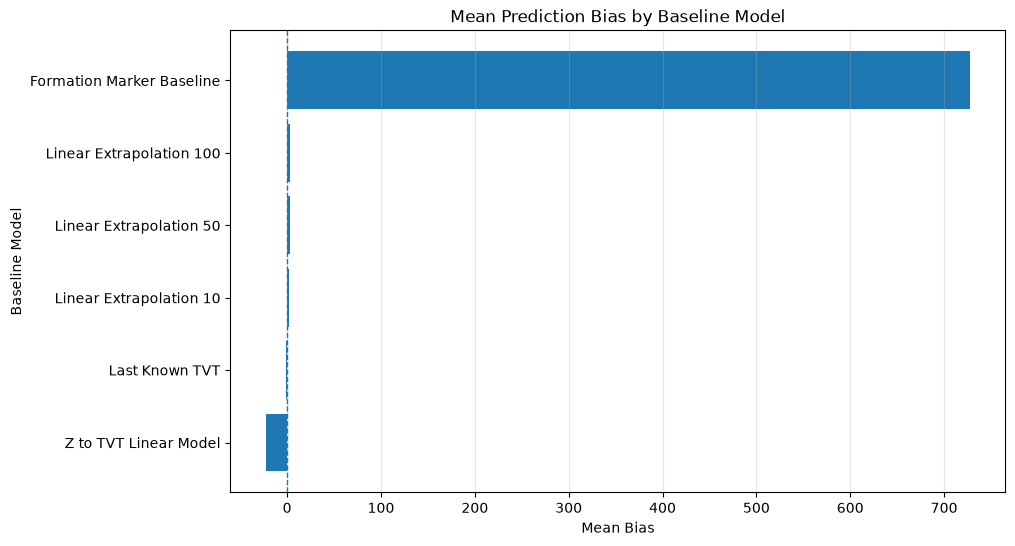

In [87]:
bias_plot_data = (
    baseline_comparison
    .sort_values(
        "Mean_Bias"
    )
)

plt.figure(figsize=(10, 6))

plt.barh(
    bias_plot_data["Model"],
    bias_plot_data[
        "Mean_Bias"
    ]
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Mean Prediction Bias by Baseline Model"
)

plt.xlabel("Mean Bias")
plt.ylabel("Baseline Model")

plt.grid(
    axis="x",
    alpha=0.3
)

plt.show()

#### 11.10 Compare Linear Extrapolation Windows

The three linear-extrapolation windows are compared separately to determine which recent-history length is most reliable across all wells.

In [88]:
linear_model_comparison = (
    baseline_comparison.loc[
        baseline_comparison[
            "Model"
        ].str.startswith(
            "Linear Extrapolation"
        )
    ]
    .sort_values(
        "Median_Well_MAE"
    )
)

display(
    linear_model_comparison[
        [
            "Model",
            "Successful_Wells",
            "Mean_Well_MAE",
            "Median_Well_MAE",
            "Median_Well_RMSE",
            "Weighted_MAE",
            "Weighted_RMSE"
        ]
    ]
)

,Model,Successful_Wells,Mean_Well_MAE,Median_Well_MAE,Median_Well_RMSE,Weighted_MAE,Weighted_RMSE
1,Linear Extrapolation 10,773,49.3559,30.5816,37.2149,53.6928,105.6554
2,Linear Extrapolation 100,773,51.2812,32.1667,36.7085,56.1481,117.2219
3,Linear Extrapolation 50,773,51.6731,32.4676,37.9880,56.4415,113.6347


In [89]:
if not linear_model_comparison.empty:
    best_linear_model = (
        linear_model_comparison
        .iloc[0][
            "Model"
        ]
    )

    print(
        "Best linear-extrapolation version:",
        best_linear_model
    )

Best linear-extrapolation version: Linear Extrapolation 10


#### 11.11 Baseline Performance Observation

Across all 773 training wells, **Last Known TVT** was the strongest baseline. It achieved the lowest median well MAE of **8.73** and the lowest median RMSE of **10.67**.

Its weighted MAE was **11.20**, which means it also performed best when longer wells with more prediction rows are given more weight. Mean well MAE was a little higher at **10.93**, showing that some difficult wells pull the average up.

**Formation Marker Baseline** produced the highest typical error, with a median well MAE of **801.03** and a weighted MAE of **964.89**. The large positive bias shows that formation-based predictions often drift far above the true TVT in the hidden section.

The **Z to TVT Linear Model** sat in the middle of the pack but was still much weaker than the constant baseline (median MAE **96.24**). Its strong negative bias suggests it often under-predicts once the known Z-TVT relationship is applied beyond Prediction Start.

Among the linear-extrapolation approaches, the **10**-row window performed best (median MAE **30.58**). The 50- and 100-row windows were slightly worse. This suggests that short-term TVT behaviour near the prediction boundary was more useful than a longer recent trend - but even the best linear model was clearly behind Last Known TVT.

The gap between mean and median error for several models shows that a smaller set of wells is much harder to predict than the typical well. Those difficult cases are inspected in the following sections.

### 12. Baseline Behaviour Analysis

The best baseline model is inspected on three representative wells:

- A good prediction with low MAE.
- An average prediction near the median MAE.
- A poor prediction with high MAE.

This helps explain where the baseline succeeds and where it fails.

#### 12.1 Select Representative Wells

In [90]:
best_model_results = (
    baseline_results.loc[
        baseline_results["Model"]
        == best_baseline_model
    ]
    .dropna(subset=["MAE"])
    .sort_values("MAE")
    .reset_index(drop=True)
)

print(
    "Best baseline model:",
    best_baseline_model
)

print(
    "Available wells:",
    len(best_model_results)
)

Best baseline model: Last Known TVT
Available wells: 773


In [91]:
good_well_row = (
    best_model_results.iloc[0]
)

poor_well_row = (
    best_model_results.iloc[-1]
)

median_mae = (
    best_model_results["MAE"].median()
)

average_index = (
    best_model_results["MAE"]
    .sub(median_mae)
    .abs()
    .idxmin()
)

average_well_row = (
    best_model_results.loc[
        average_index
    ]
)

example_wells = pd.DataFrame([
    {
        "Category": "Good Prediction",
        "Well_ID": good_well_row["Well_ID"],
        "MAE": good_well_row["MAE"],
        "RMSE": good_well_row["RMSE"],
        "Bias": good_well_row["Bias"]
    },
    {
        "Category": "Average Prediction",
        "Well_ID": average_well_row["Well_ID"],
        "MAE": average_well_row["MAE"],
        "RMSE": average_well_row["RMSE"],
        "Bias": average_well_row["Bias"]
    },
    {
        "Category": "Poor Prediction",
        "Well_ID": poor_well_row["Well_ID"],
        "MAE": poor_well_row["MAE"],
        "RMSE": poor_well_row["RMSE"],
        "Bias": poor_well_row["Bias"]
    }
])

display(example_wells)

,Category,Well_ID,MAE,RMSE,Bias
0,Good Prediction,283269ac_,0.8203,1.1159,0.4801
1,Average Prediction,74b6186b_,8.7286,9.0072,-8.7286
2,Poor Prediction,1b1eba53_,65.9312,70.6394,-65.9312


#### 12.2 Generate Predictions for the Selected Baseline

This helper function applies the selected best baseline model to any horizontal well.

It returns predictions only for the rows where `TVT_input` is missing.

In [92]:
def generate_baseline_predictions(
    horizontal_data,
    model_name
):
    if model_name == "Last Known TVT":
        result = predict_last_known_tvt(
            horizontal_data
        )

        return result["Predictions"]

    if model_name.startswith(
        "Linear Extrapolation"
    ):
        window = int(
            model_name.split()[-1]
        )

        result = predict_linear_extrapolation(
            horizontal_data,
            window=window
        )

        if result is None:
            return None

        return result["Predictions"]

    if model_name == "Z to TVT Linear Model":
        result = predict_tvt_from_z(
            horizontal_data
        )

        if result is None:
            return None

        return result["Predictions"]

    if model_name == "Formation Marker Baseline":
        result = predict_from_best_formation(
            horizontal_data
        )

        if result is None:
            return None

        return result["Predictions"]

    raise ValueError(
        f"Unknown baseline model: {model_name}"
    )

#### 12.3 Create the Prediction Plotting Function

This function compares:

- The complete actual TVT curve
- The visible `TVT_input`
- The prediction from the best baseline model
- The prediction-start boundary

In [93]:
def plot_baseline_prediction(
    well_id,
    model_name,
    category
):
    horizontal_data = pd.read_csv(
        horizontal_map[well_id]
    )

    known_mask, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    predictions = generate_baseline_predictions(
        horizontal_data,
        model_name
    )

    if predictions is None:
        print(
            f"No valid prediction was created "
            f"for well {well_id}."
        )
        return

    if len(predictions) != int(
        prediction_mask.sum()
    ):
        raise ValueError(
            "Prediction length does not match "
            "the number of prediction rows."
        )

    prediction_information = (
        get_prediction_information(
            horizontal_data
        )
    )

    actual_prediction_tvt = (
        horizontal_data.loc[
            prediction_mask,
            "TVT"
        ]
        .to_numpy()
    )

    metrics = calculate_regression_metrics(
        actual_prediction_tvt,
        predictions
    )

    full_predictions = np.full(
        len(horizontal_data),
        np.nan
    )

    full_predictions[
        prediction_mask.to_numpy()
    ] = predictions

    plt.figure(figsize=(14, 6))

    plt.plot(
        horizontal_data["MD"],
        horizontal_data["TVT"],
        linewidth=1.5,
        label="Actual TVT"
    )

    plt.plot(
        horizontal_data["MD"],
        horizontal_data["TVT_input"],
        linewidth=2,
        label="Visible TVT_input"
    )

    plt.plot(
        horizontal_data["MD"],
        full_predictions,
        linestyle="--",
        linewidth=2,
        label=model_name
    )

    plt.axvline(
        prediction_information[
            "Prediction_Start_MD"
        ],
        linestyle=":",
        label="Prediction Start"
    )

    plt.title(
        f"{category} – Well {well_id}\n"
        f"MAE: {metrics['MAE']:.4f} | "
        f"RMSE: {metrics['RMSE']:.4f} | "
        f"Bias: {metrics['Bias']:.4f}"
    )

    plt.xlabel("Measured Depth (MD)")
    plt.ylabel("TVT")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

#### 12.4 Good Prediction Example

The lowest-error well is visualized to understand why the selected baseline works well in this case.

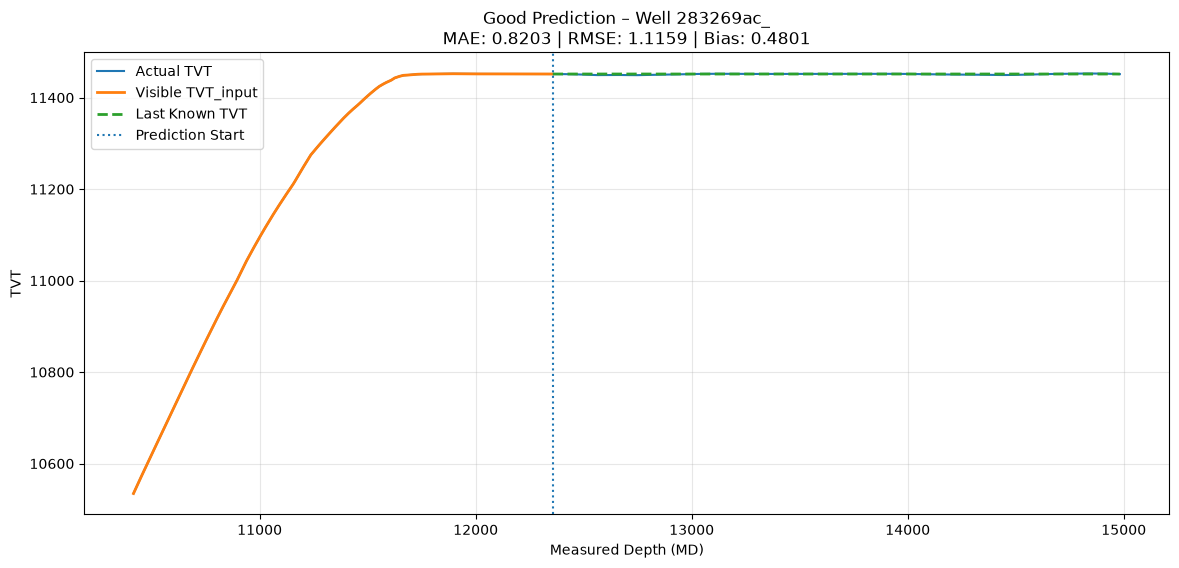

In [94]:
plot_baseline_prediction(
    well_id=good_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Good Prediction"
)

#### 12.5 Average Prediction Example

The well closest to the median MAE represents typical baseline performance across the dataset.

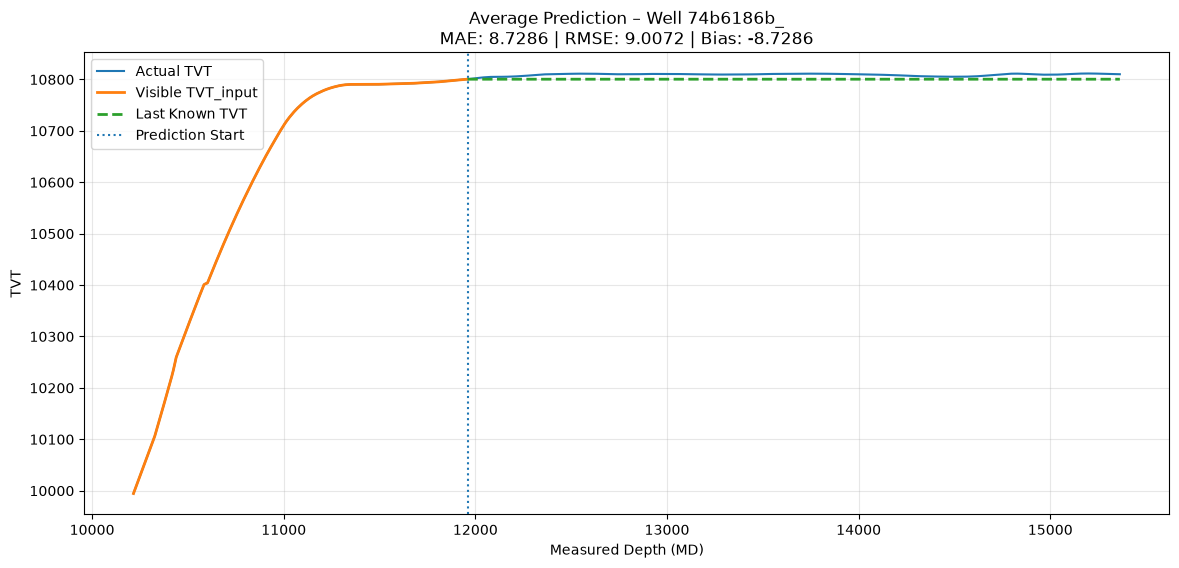

In [95]:
plot_baseline_prediction(
    well_id=average_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Average Prediction"
)

#### 12.6 Poor Prediction Example

The highest-error well is visualized to identify the conditions under which the baseline fails.

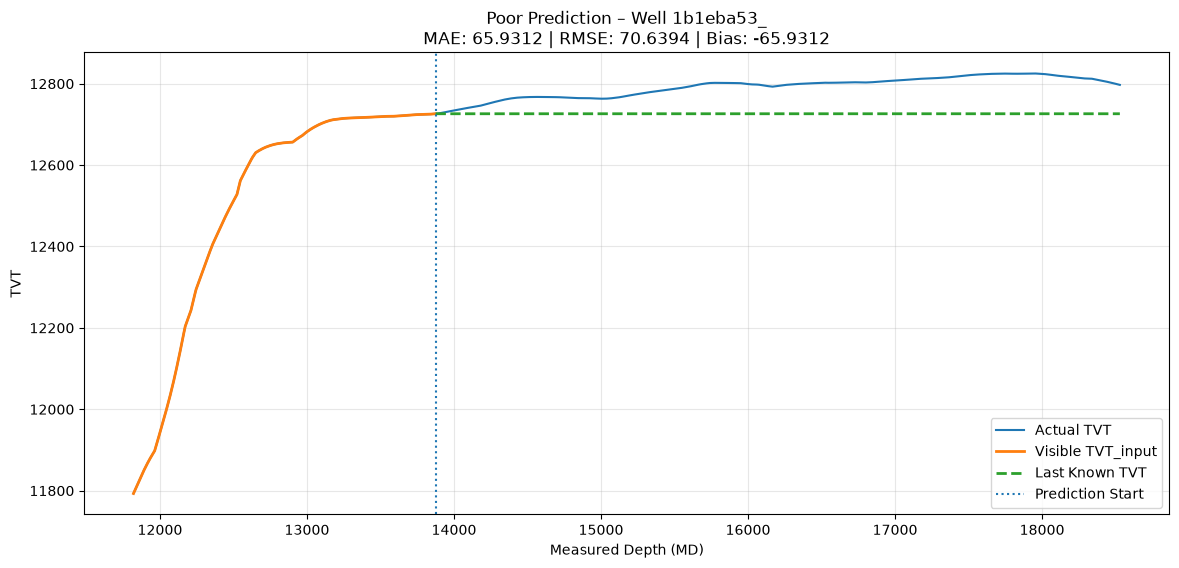

In [96]:
plot_baseline_prediction(
    well_id=poor_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Poor Prediction"
)

#### 12.7 Error Growth Analysis - Plot Absolute Error Along MD

The absolute error is plotted across the prediction section.

This shows whether the error increases as the model predicts farther away from the known TVT boundary.

In [97]:
def plot_absolute_error(
    well_id,
    model_name,
    category
):
    horizontal_data = pd.read_csv(
        horizontal_map[well_id]
    )

    _, prediction_mask = (
        identify_prediction_sections(
            horizontal_data
        )
    )

    predictions = generate_baseline_predictions(
        horizontal_data,
        model_name
    )

    if predictions is None:
        print(
            f"No valid prediction was created "
            f"for well {well_id}."
        )
        return

    prediction_md = (
        horizontal_data.loc[
            prediction_mask,
            "MD"
        ]
        .to_numpy()
    )

    actual_tvt = (
        horizontal_data.loc[
            prediction_mask,
            "TVT"
        ]
        .to_numpy()
    )

    absolute_error = np.abs(
        predictions - actual_tvt
    )

    plt.figure(figsize=(14, 5))

    plt.plot(
        prediction_md,
        absolute_error,
        linewidth=1
    )

    plt.title(
        f"Absolute Error – "
        f"{category} – Well {well_id}"
    )

    plt.xlabel("Measured Depth (MD)")
    plt.ylabel("Absolute TVT Error")

    plt.grid(alpha=0.3)
    plt.show()

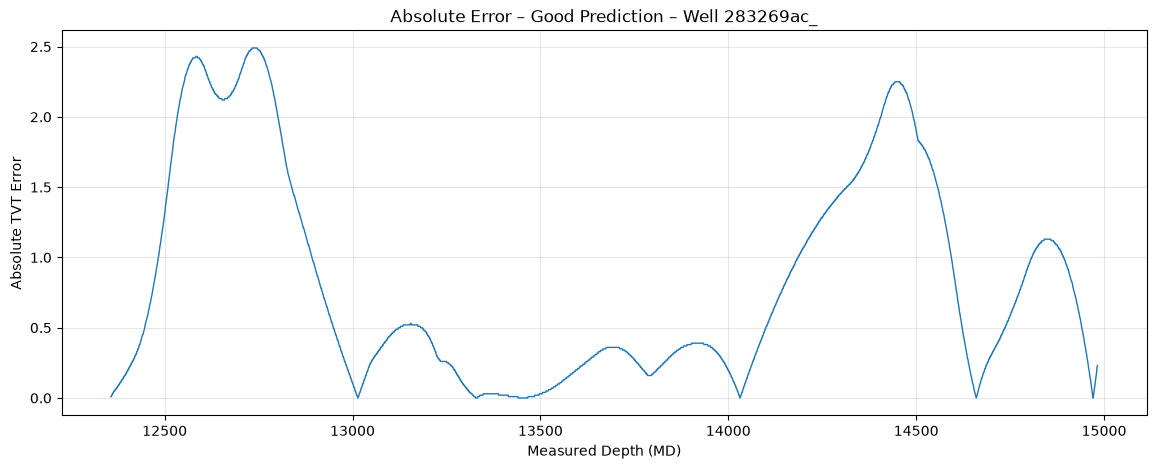

In [98]:
plot_absolute_error(
    well_id=good_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Good Prediction"
)

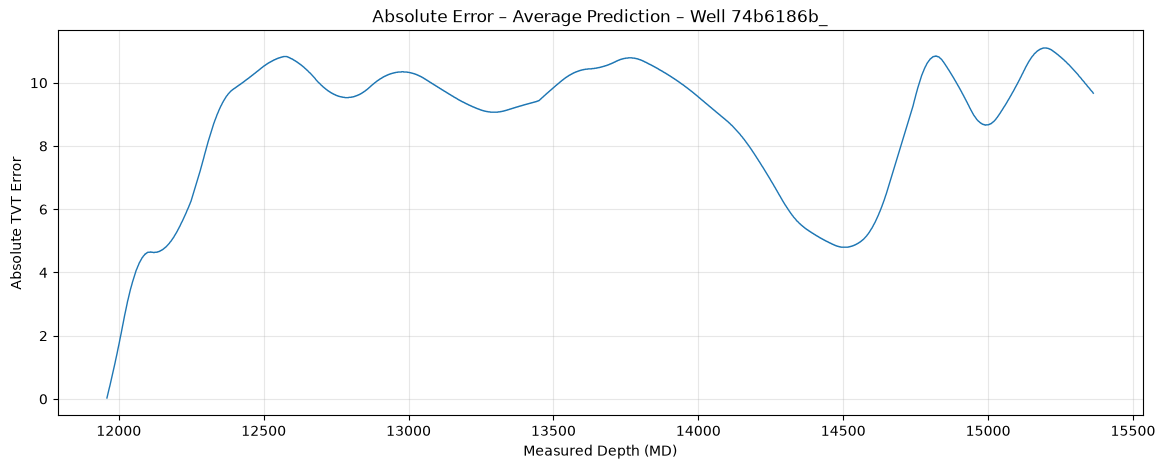

In [99]:
plot_absolute_error(
    well_id=average_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Average Prediction"
)

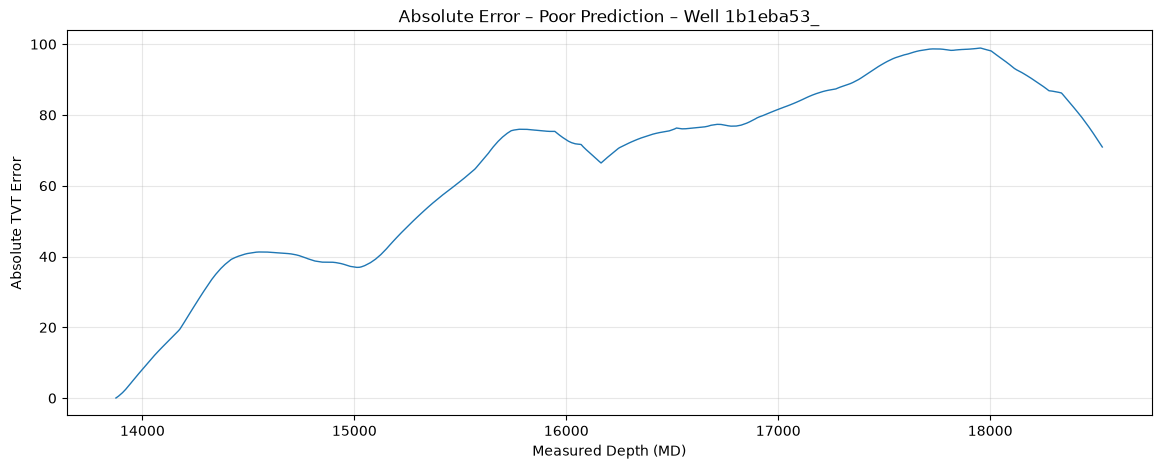

In [100]:
plot_absolute_error(
    well_id=poor_well_row["Well_ID"],
    model_name=best_baseline_model,
    category="Poor Prediction"
)

### 12.8 Prediction Example Observation

These examples use the best baseline, **Last Known TVT**, on three wells from the full training set.

**Good prediction** (`283269ac_`, MAE **0.82**, RMSE **1.12**)

After Prediction Start the true TVT stays almost flat, so the constant hold sits almost on top of the actual curve. Absolute error stays very small — mostly under about 2.5 — with long stretches close to zero.

**Average prediction** (`74b6186b_`, MAE **8.73**, RMSE **9.01**)

This well is near the dataset median error. The true TVT remains broadly flat but sits a little above the last known value for most of the prediction section, which creates a steady negative bias of about **-8.73**. Absolute error quickly rises and then stays in a band around 5–11 rather than growing without bound.

**Poor prediction** (`1b1eba53_`, MAE **65.93**, RMSE **70.64**)

Here the constant baseline fails clearly. After Prediction Start the true TVT keeps rising, while the green last-known line stays flat. The model under-predicts all the way through (bias about **-65.93**). Absolute error climbs with MD and peaks near **100** toward the far end of the well before easing slightly.

Together, these plots show that Last Known TVT works when the hidden section stays close to the final visible value, and breaks down when TVT keeps trending after the prediction boundary. That pattern matches the earlier dataset-wide result: the constant baseline is a strong average benchmark, but a smaller set of wells still needs a method that can follow changing TVT.

### 13. Failure Analysis & Feature Discovery

The previous sections showed that baseline performance varies considerably between wells.  
However, ranking wells by error alone does not explain why the models fail.

This section investigates whether prediction errors are associated with:

- Prediction horizon length
- Horizontal-well trajectory geometry
- TVT changes after the prediction start
- Gamma-ray behaviour
- Formation-marker availability
- Differences between the typewell and horizontal well
- Extrapolation beyond the typewell TVT range

The findings from this analysis will guide feature engineering and model development in Notebook 05.

#### 13.1 Prepare Well-Level Failure Analysis Dataset

A well-level analysis table is created by combining baseline errors with structural and geological characteristics of each well pair.

Each row represents one well and contains information such as:

- Number of prediction rows
- Prediction horizon in measured depth
- TVT variation
- Gamma-ray statistics
- Formation-marker coverage
- Typewell and horizontal-well differences
- Baseline model errors

This table allows relationships between well characteristics and model failure to be investigated systematically.

In [101]:
def calculate_well_failure_features(
    well_id,
    typewell_df,
    horizontal_df
):
    """
    Calculate well-level characteristics that may explain baseline failure.
    """

    horizontal_df = horizontal_df.copy()
    typewell_df = typewell_df.copy()

    # Identify the prediction region
    prediction_mask = horizontal_df["TVT_input"].isna()

    known_df = horizontal_df.loc[~prediction_mask].copy()
    prediction_df = horizontal_df.loc[prediction_mask].copy()

    features = {
        "well_id": well_id,
        "n_typewell_rows": len(typewell_df),
        "n_horizontal_rows": len(horizontal_df),
        "n_known_rows": len(known_df),
        "n_prediction_rows": len(prediction_df),
        "prediction_fraction": prediction_mask.mean(),
    }

    # Prediction horizon characteristics
    if len(prediction_df) > 0:
        features["prediction_md_start"] = prediction_df["MD"].min()
        features["prediction_md_end"] = prediction_df["MD"].max()
        features["prediction_md_horizon"] = (
            features["prediction_md_end"]
            - features["prediction_md_start"]
        )
    else:
        features["prediction_md_start"] = np.nan
        features["prediction_md_end"] = np.nan
        features["prediction_md_horizon"] = 0.0

    # Known horizontal TVT characteristics
    if len(known_df) > 0:
        features["known_tvt_min"] = known_df["TVT"].min()
        features["known_tvt_max"] = known_df["TVT"].max()
        features["known_tvt_range"] = (
            features["known_tvt_max"]
            - features["known_tvt_min"]
        )
        features["last_known_tvt"] = known_df["TVT"].iloc[-1]
    else:
        features["known_tvt_min"] = np.nan
        features["known_tvt_max"] = np.nan
        features["known_tvt_range"] = np.nan
        features["last_known_tvt"] = np.nan

    # Actual TVT behaviour inside the prediction region
    if len(prediction_df) > 0:
        features["prediction_tvt_min"] = prediction_df["TVT"].min()
        features["prediction_tvt_max"] = prediction_df["TVT"].max()
        features["prediction_tvt_range"] = (
            features["prediction_tvt_max"]
            - features["prediction_tvt_min"]
        )
        features["prediction_tvt_std"] = prediction_df["TVT"].std()
        features["prediction_tvt_change"] = (
            prediction_df["TVT"].iloc[-1]
            - features["last_known_tvt"]
        )
    else:
        features["prediction_tvt_min"] = np.nan
        features["prediction_tvt_max"] = np.nan
        features["prediction_tvt_range"] = np.nan
        features["prediction_tvt_std"] = np.nan
        features["prediction_tvt_change"] = np.nan

    # Gamma-ray characteristics
    if "GR" in prediction_df.columns and len(prediction_df) > 0:
        features["prediction_gr_mean"] = prediction_df["GR"].mean()
        features["prediction_gr_std"] = prediction_df["GR"].std()
        features["prediction_gr_range"] = (
            prediction_df["GR"].max()
            - prediction_df["GR"].min()
        )
        features["prediction_gr_missing_fraction"] = (
            prediction_df["GR"].isna().mean()
        )
    else:
        features["prediction_gr_mean"] = np.nan
        features["prediction_gr_std"] = np.nan
        features["prediction_gr_range"] = np.nan
        features["prediction_gr_missing_fraction"] = np.nan

    # Typewell characteristics
    features["typewell_tvt_min"] = typewell_df["TVT"].min()
    features["typewell_tvt_max"] = typewell_df["TVT"].max()
    features["typewell_tvt_range"] = (
        features["typewell_tvt_max"]
        - features["typewell_tvt_min"]
    )

    features["typewell_gr_mean"] = typewell_df["GR"].mean()
    features["typewell_gr_std"] = typewell_df["GR"].std()

    # Difference between horizontal and typewell gamma ray
    features["gr_mean_difference"] = abs(
        features["prediction_gr_mean"]
        - features["typewell_gr_mean"]
    )

    # Formation-marker coverage
    formation_columns = [
        "ANCC",
        "ASTNU",
        "ASTNL",
        "EGFDU",
        "EGFDL",
        "BUDA",
    ]

    available_markers = [
        column
        for column in formation_columns
        if column in horizontal_df.columns
    ]

    if available_markers and len(prediction_df) > 0:
        features["formation_marker_count"] = (
            prediction_df[available_markers]
            .notna()
            .sum()
            .sum()
        )

        features["formation_marker_coverage"] = (
            prediction_df[available_markers]
            .notna()
            .mean()
            .mean()
        )
    else:
        features["formation_marker_count"] = 0
        features["formation_marker_coverage"] = 0.0

    return features

In [104]:
failure_feature_records = []

for well_id in complete_ids:
    typewell_df = pd.read_csv(
        typewell_map[well_id]
    )
    horizontal_df = pd.read_csv(
        horizontal_map[well_id]
    )

    well_features = calculate_well_failure_features(
        well_id=well_id,
        typewell_df=typewell_df,
        horizontal_df=horizontal_df
    )

    failure_feature_records.append(well_features)

failure_features_df = pd.DataFrame(failure_feature_records)

print("Failure feature dataset shape:", failure_features_df.shape)

display(failure_features_df.head())

Failure feature dataset shape: (773, 29)


,well_id,n_typewell_rows,n_horizontal_rows,n_known_rows,n_prediction_rows,prediction_fraction,prediction_md_start,prediction_md_end,prediction_md_horizon,known_tvt_min,known_tvt_max,known_tvt_range,last_known_tvt,tvt_input_min,tvt_input_max,tvt_input_range,tvt_input_std,prediction_gr_mean,prediction_gr_std,prediction_gr_range,prediction_gr_missing_fraction,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,gr_mean_difference,formation_marker_count,formation_marker_coverage
0,000d7d20_,1296,5278,5278,0,0.0000,NaN,NaN,0.0000,"11,236.0200","11,756.1200",520.1000,"11,737.3100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,223.9500","11,871.4500",647.5000,83.2576,26.2513,NaN,0,0.0000
1,00bbac68_,1946,7559,7559,0,0.0000,NaN,NaN,0.0000,"11,406.6300","12,240.0100",833.3800,"12,216.8000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,394.4500","12,366.9500",972.5000,92.3442,27.6612,NaN,0,0.0000
2,00e12e8b_,2556,6384,6384,0,0.0000,NaN,NaN,0.0000,"10,606.1800","11,616.6400","1,010.4600","11,596.3700",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10,593.9500","11,871.4500","1,277.5000",95.7690,23.5013,NaN,0,0.0000
3,015fe0d2_,1265,5950,5950,0,0.0000,NaN,NaN,0.0000,"11,747.2600","12,271.5300",524.2700,"12,257.7600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,734.9500","12,366.9500",632.0000,81.7350,27.5799,NaN,0,0.0000
4,01869cd4_,1052,6850,6850,0,0.0000,NaN,NaN,0.0000,"11,358.2700","11,767.7500",409.4800,"11,749.3900",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,345.9500","11,871.4500",525.5000,76.8923,24.3299,NaN,0,0.0000


#### 13.2 Combine Failure Features with Baseline Results

The newly calculated well characteristics are merged with the baseline evaluation results.

This produces a single dataset containing both:

- Explanatory well characteristics
- Model performance metrics

The merged dataset will be used to identify which conditions are associated with high prediction errors.

In [109]:
print("Long-format baseline result columns:")
print(baseline_results.columns.tolist())

# Convert to one row per well with error columns for each baseline
baseline_results_df = (
    baseline_results
    .pivot_table(
        index="Well_ID",
        columns="Model",
        values=["MAE", "RMSE", "Bias"],
        aggfunc="first"
    )
)

baseline_results_df.columns = [
    f"{metric}_{model}".replace(" ", "_")
    for metric, model in baseline_results_df.columns
]

baseline_results_df = (
    baseline_results_df
    .reset_index()
    .rename(columns={"Well_ID": "well_id"})
)

print("\nWell-level baseline result columns:")
print(baseline_results_df.columns.tolist())

display(baseline_results_df.head())

failure_analysis_df = failure_features_df.merge(
    baseline_results_df,
    on="well_id",
    how="inner"
)

print("\nFailure analysis dataset shape:", failure_analysis_df.shape)

display(failure_analysis_df.head())


Long-format baseline result columns:
['Well_ID', 'Model', 'Parameter', 'MAE', 'RMSE', 'Bias', 'Evaluation_Rows']

Well-level baseline result columns:
['well_id', 'Bias_Formation_Marker_Baseline', 'Bias_Last_Known_TVT', 'Bias_Linear_Extrapolation_10', 'Bias_Linear_Extrapolation_100', 'Bias_Linear_Extrapolation_50', 'Bias_Z_to_TVT_Linear_Model', 'MAE_Formation_Marker_Baseline', 'MAE_Last_Known_TVT', 'MAE_Linear_Extrapolation_10', 'MAE_Linear_Extrapolation_100', 'MAE_Linear_Extrapolation_50', 'MAE_Z_to_TVT_Linear_Model', 'RMSE_Formation_Marker_Baseline', 'RMSE_Last_Known_TVT', 'RMSE_Linear_Extrapolation_10', 'RMSE_Linear_Extrapolation_100', 'RMSE_Linear_Extrapolation_50', 'RMSE_Z_to_TVT_Linear_Model']


,well_id,Bias_Formation_Marker_Baseline,Bias_Last_Known_TVT,Bias_Linear_Extrapolation_10,Bias_Linear_Extrapolation_100,Bias_Linear_Extrapolation_50,Bias_Z_to_TVT_Linear_Model,MAE_Formation_Marker_Baseline,MAE_Last_Known_TVT,MAE_Linear_Extrapolation_10,MAE_Linear_Extrapolation_100,MAE_Linear_Extrapolation_50,MAE_Z_to_TVT_Linear_Model,RMSE_Formation_Marker_Baseline,RMSE_Last_Known_TVT,RMSE_Linear_Extrapolation_10,RMSE_Linear_Extrapolation_100,RMSE_Linear_Extrapolation_50,RMSE_Z_to_TVT_Linear_Model
0,000d7d20_,675.6698,5.4456,27.0723,29.3775,37.4755,-58.2800,675.6698,6.1350,27.0882,29.3843,37.4755,58.2800,760.5518,7.4544,32.1078,34.7624,44.0944,64.6276
1,00bbac68_,711.2269,2.5219,53.7405,25.3485,41.8237,-103.2780,711.2269,12.1043,53.8339,25.9515,41.9948,103.2780,806.0412,15.2631,68.0760,36.4757,54.6432,115.5915
2,00e12e8b_,"-1,222.2883",0.7603,90.0594,79.7339,91.3947,-100.6013,"1,222.2883",6.5199,90.0595,79.7401,91.3947,100.6013,"1,281.9894",7.9246,106.4947,94.6039,108.0329,107.2139
3,015fe0d2_,677.4439,-19.7496,43.5335,35.8563,44.4640,79.1514,677.4439,19.8002,43.5335,35.8786,44.4640,79.1514,774.0036,23.1549,52.0031,43.2684,53.0647,88.8116
4,01869cd4_,311.4829,-4.4678,-1.7730,36.9991,19.1868,85.6906,311.4829,8.6357,7.0036,36.9991,19.1868,85.6906,347.5873,10.6186,8.8038,41.3987,21.5488,95.0579



Failure analysis dataset shape: (773, 47)


,well_id,n_typewell_rows,n_horizontal_rows,n_known_rows,n_prediction_rows,prediction_fraction,prediction_md_start,prediction_md_end,prediction_md_horizon,known_tvt_min,known_tvt_max,known_tvt_range,last_known_tvt,tvt_input_min,tvt_input_max,tvt_input_range,tvt_input_std,prediction_gr_mean,prediction_gr_std,prediction_gr_range,prediction_gr_missing_fraction,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,gr_mean_difference,formation_marker_count,formation_marker_coverage,Bias_Formation_Marker_Baseline,Bias_Last_Known_TVT,Bias_Linear_Extrapolation_10,Bias_Linear_Extrapolation_100,Bias_Linear_Extrapolation_50,Bias_Z_to_TVT_Linear_Model,MAE_Formation_Marker_Baseline,MAE_Last_Known_TVT,MAE_Linear_Extrapolation_10,MAE_Linear_Extrapolation_100,MAE_Linear_Extrapolation_50,MAE_Z_to_TVT_Linear_Model,RMSE_Formation_Marker_Baseline,RMSE_Last_Known_TVT,RMSE_Linear_Extrapolation_10,RMSE_Linear_Extrapolation_100,RMSE_Linear_Extrapolation_50,RMSE_Z_to_TVT_Linear_Model
0,000d7d20_,1296,5278,5278,0,0.0000,NaN,NaN,0.0000,"11,236.0200","11,756.1200",520.1000,"11,737.3100",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,223.9500","11,871.4500",647.5000,83.2576,26.2513,NaN,0,0.0000,675.6698,5.4456,27.0723,29.3775,37.4755,-58.2800,675.6698,6.1350,27.0882,29.3843,37.4755,58.2800,760.5518,7.4544,32.1078,34.7624,44.0944,64.6276
1,00bbac68_,1946,7559,7559,0,0.0000,NaN,NaN,0.0000,"11,406.6300","12,240.0100",833.3800,"12,216.8000",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,394.4500","12,366.9500",972.5000,92.3442,27.6612,NaN,0,0.0000,711.2269,2.5219,53.7405,25.3485,41.8237,-103.2780,711.2269,12.1043,53.8339,25.9515,41.9948,103.2780,806.0412,15.2631,68.0760,36.4757,54.6432,115.5915
2,00e12e8b_,2556,6384,6384,0,0.0000,NaN,NaN,0.0000,"10,606.1800","11,616.6400","1,010.4600","11,596.3700",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"10,593.9500","11,871.4500","1,277.5000",95.7690,23.5013,NaN,0,0.0000,"-1,222.2883",0.7603,90.0594,79.7339,91.3947,-100.6013,"1,222.2883",6.5199,90.0595,79.7401,91.3947,100.6013,"1,281.9894",7.9246,106.4947,94.6039,108.0329,107.2139
3,015fe0d2_,1265,5950,5950,0,0.0000,NaN,NaN,0.0000,"11,747.2600","12,271.5300",524.2700,"12,257.7600",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,734.9500","12,366.9500",632.0000,81.7350,27.5799,NaN,0,0.0000,677.4439,-19.7496,43.5335,35.8563,44.4640,79.1514,677.4439,19.8002,43.5335,35.8786,44.4640,79.1514,774.0036,23.1549,52.0031,43.2684,53.0647,88.8116
4,01869cd4_,1052,6850,6850,0,0.0000,NaN,NaN,0.0000,"11,358.2700","11,767.7500",409.4800,"11,749.3900",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"11,345.9500","11,871.4500",525.5000,76.8923,24.3299,NaN,0,0.0000,311.4829,-4.4678,-1.7730,36.9991,19.1868,85.6906,311.4829,8.6357,7.0036,36.9991,19.1868,85.6906,347.5873,10.6186,8.8038,41.3987,21.5488,95.0579


In [110]:
print(
    "Unique wells:",
    failure_analysis_df["well_id"].nunique()
)

print(
    "Duplicate well rows:",
    failure_analysis_df["well_id"].duplicated().sum()
)

display(
    failure_analysis_df.isna().mean().sort_values(
        ascending=False
    ).head(15)
)


Unique wells: 773
Duplicate well rows: 0


prediction_md_start              1.0000
tvt_input_max                    1.0000
prediction_md_end                1.0000
tvt_input_min                    1.0000
prediction_gr_mean               1.0000
tvt_input_std                    1.0000
tvt_input_range                  1.0000
prediction_gr_std                1.0000
gr_mean_difference               1.0000
prediction_gr_missing_fraction   1.0000
prediction_gr_range              1.0000
prediction_fraction              0.0000
n_horizontal_rows                0.0000
n_typewell_rows                  0.0000
well_id                          0.0000
dtype: float64

#### 13.3 Define the Best Baseline Error

Different baseline models may perform best on different wells.

To measure the remaining difficulty of each well, the minimum RMSE across all baseline models is calculated. A well with a high minimum RMSE is difficult even for the strongest baseline available.

This metric is referred to as `best_baseline_rmse`.

In [111]:
rmse_columns = [
    column
    for column in failure_analysis_df.columns
    if "rmse" in column.lower()
]

print("Detected RMSE columns:")
for column in rmse_columns:
    print("-", column)

Detected RMSE columns:
- RMSE_Formation_Marker_Baseline
- RMSE_Last_Known_TVT
- RMSE_Linear_Extrapolation_10
- RMSE_Linear_Extrapolation_100
- RMSE_Linear_Extrapolation_50
- RMSE_Z_to_TVT_Linear_Model


In [112]:
failure_analysis_df["best_baseline_rmse"] = (
    failure_analysis_df[rmse_columns]
    .min(axis=1)
)

failure_analysis_df["best_baseline_model"] = (
    failure_analysis_df[rmse_columns]
    .idxmin(axis=1)
    .str.replace("_rmse", "", regex=False)
)

failure_analysis_df[
    [
        "well_id",
        "best_baseline_model",
        "best_baseline_rmse"
    ]
].head()

,well_id,best_baseline_model,best_baseline_rmse
0,000d7d20_,RMSE_Last_Known_TVT,7.4544
1,00bbac68_,RMSE_Last_Known_TVT,15.2631
2,00e12e8b_,RMSE_Last_Known_TVT,7.9246
3,015fe0d2_,RMSE_Last_Known_TVT,23.1549
4,01869cd4_,RMSE_Linear_Extrapolation_10,8.8038


In [113]:
failure_analysis_df["best_baseline_rmse"].describe()

count   773.0000
mean     11.5278
std       7.8417
min       1.1159
25%       6.3657
50%       9.6859
75%      14.1749
max      65.3587
Name: best_baseline_rmse, dtype: float64

#### 13.4 Relationship Between Well Characteristics and Prediction Error

This analysis measures how strongly each well characteristic is associated with baseline prediction error.

A positive correlation means that the baseline error generally increases as the feature increases. A negative correlation means that error generally decreases as the feature increases.

Correlation does not prove causation, but it helps identify promising variables for feature engineering.

In [114]:
analysis_feature_columns = [
    "n_prediction_rows",
    "prediction_fraction",
    "prediction_md_horizon",
    "known_tvt_range",
    "tvt_input_range",
    "tvt_input_std",
    "prediction_gr_mean",
    "prediction_gr_std",
    "prediction_gr_range",
    "prediction_gr_missing_fraction",
    "typewell_tvt_range",
    "typewell_gr_std",
    "gr_mean_difference",
    "formation_marker_count",
    "formation_marker_coverage",
]

available_analysis_features = [
    column
    for column in analysis_feature_columns
    if column in failure_analysis_df.columns
]

correlation_series = (
    failure_analysis_df[
        available_analysis_features + ["best_baseline_rmse"]
    ]
    .corr(numeric_only=True)["best_baseline_rmse"]
    .drop("best_baseline_rmse")
    .sort_values(key=abs, ascending=False)
)

correlation_df = correlation_series.reset_index()
correlation_df.columns = ["feature", "correlation_with_rmse"]

correlation_df

,feature,correlation_with_rmse
0,known_tvt_range,0.0871
1,typewell_tvt_range,0.0308
2,typewell_gr_std,0.0100
3,n_prediction_rows,NaN
4,prediction_fraction,NaN
5,prediction_md_horizon,NaN
6,tvt_input_range,NaN
7,tvt_input_std,NaN
8,prediction_gr_mean,NaN
9,prediction_gr_std,NaN


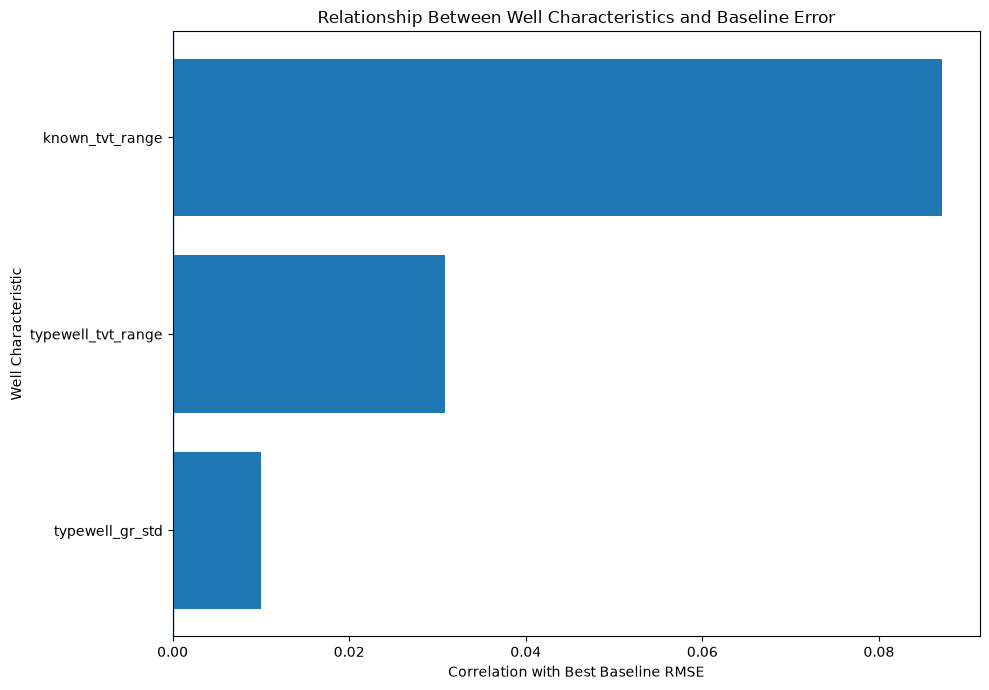

In [115]:
plt.figure(figsize=(10, 7))

plt.barh(
    correlation_df["feature"],
    correlation_df["correlation_with_rmse"]
)

plt.axvline(0, linewidth=1)
plt.xlabel("Correlation with Best Baseline RMSE")
plt.ylabel("Well Characteristic")
plt.title("Relationship Between Well Characteristics and Baseline Error")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### 13.5 Compare Easy and Difficult Wells

The wells are divided into three groups based on their best baseline RMSE:

- Easy wells: lowest 25% of errors
- Moderate wells: middle 50%
- Difficult wells: highest 25% of errors

Comparing these groups helps identify structural differences between wells where baseline predictions succeed and wells where they fail.

In [116]:
lower_error_threshold = failure_analysis_df[
    "best_baseline_rmse"
].quantile(0.25)

upper_error_threshold = failure_analysis_df[
    "best_baseline_rmse"
].quantile(0.75)


def assign_difficulty_group(rmse):
    if rmse <= lower_error_threshold:
        return "Easy"
    elif rmse >= upper_error_threshold:
        return "Difficult"
    else:
        return "Moderate"


failure_analysis_df["difficulty_group"] = (
    failure_analysis_df["best_baseline_rmse"]
    .apply(assign_difficulty_group)
)

failure_analysis_df["difficulty_group"].value_counts()

difficulty_group
Moderate     385
Difficult    194
Easy         194
Name: count, dtype: int64

In [117]:
difficulty_summary_df = (
    failure_analysis_df
    .groupby("difficulty_group")[available_analysis_features]
    .median()
    .T
)

difficulty_summary_df

difficulty_group,Difficult,Easy,Moderate
n_prediction_rows,0.0000,0.0000,0.0000
prediction_fraction,0.0000,0.0000,0.0000
prediction_md_horizon,0.0000,0.0000,0.0000
known_tvt_range,781.8050,753.2500,757.3700
tvt_input_range,NaN,NaN,NaN
tvt_input_std,NaN,NaN,NaN
prediction_gr_mean,NaN,NaN,NaN
prediction_gr_std,NaN,NaN,NaN
prediction_gr_range,NaN,NaN,NaN
prediction_gr_missing_fraction,NaN,NaN,NaN


In [118]:
difficulty_comparison_df = pd.DataFrame({
    "easy_median": difficulty_summary_df["Easy"],
    "difficult_median": difficulty_summary_df["Difficult"],
})

difficulty_comparison_df["absolute_difference"] = (
    difficulty_comparison_df["difficult_median"]
    - difficulty_comparison_df["easy_median"]
)

difficulty_comparison_df["relative_difference_percent"] = (
    difficulty_comparison_df["absolute_difference"]
    / difficulty_comparison_df["easy_median"].abs().replace(0, np.nan)
    * 100
)

difficulty_comparison_df.sort_values(
    "absolute_difference",
    key=abs,
    ascending=False
)

,easy_median,difficult_median,absolute_difference,relative_difference_percent
known_tvt_range,753.2500,781.8050,28.5550,3.7909
typewell_tvt_range,902.2500,908.0000,5.7500,0.6373
typewell_gr_std,28.5697,28.6485,0.0788,0.2756
n_prediction_rows,0.0000,0.0000,0.0000,NaN
prediction_md_horizon,0.0000,0.0000,0.0000,NaN
prediction_fraction,0.0000,0.0000,0.0000,NaN
formation_marker_count,0.0000,0.0000,0.0000,NaN
formation_marker_coverage,0.0000,0.0000,0.0000,NaN
tvt_input_range,NaN,NaN,NaN,NaN
tvt_input_std,NaN,NaN,NaN,NaN


#### 13.6 Visualize Important Failure Relationships

In [119]:
top_failure_features = (
    correlation_df
    .head(6)["feature"]
    .tolist()
)

print("Top failure-related features:")
for feature in top_failure_features:
    print("-", feature)

Top failure-related features:
- known_tvt_range
- typewell_tvt_range
- typewell_gr_std
- n_prediction_rows
- prediction_fraction
- prediction_md_horizon


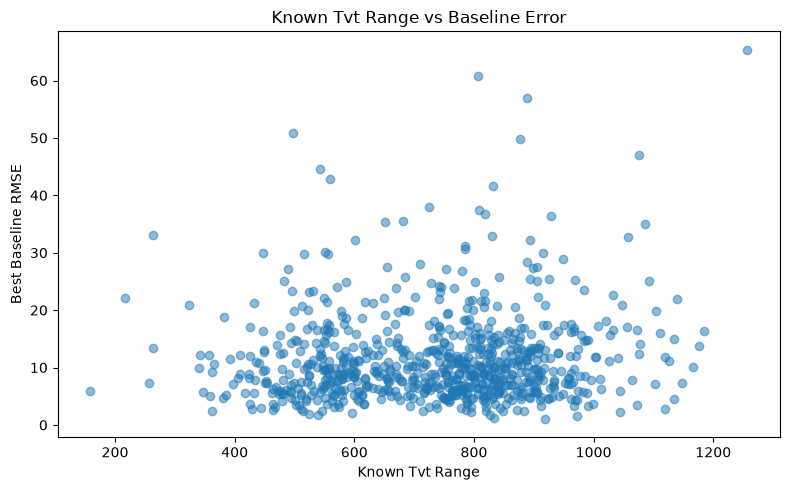

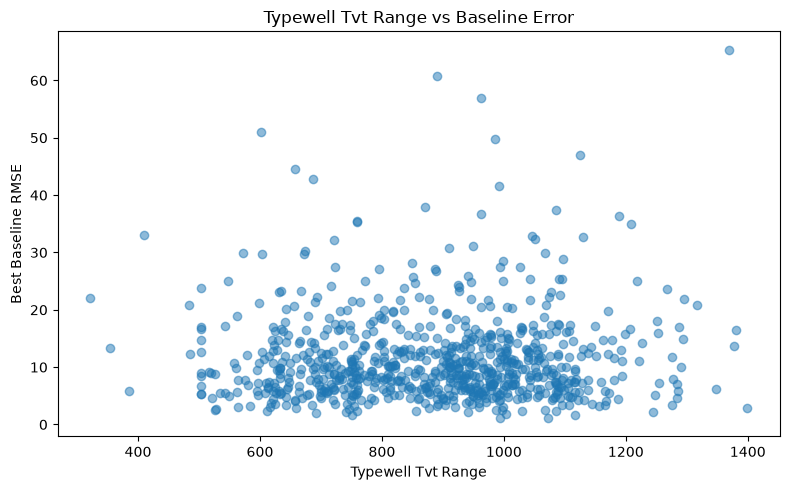

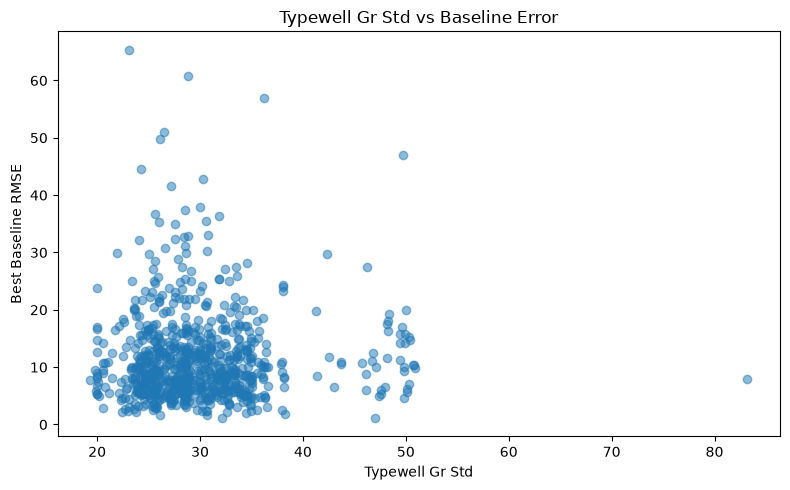

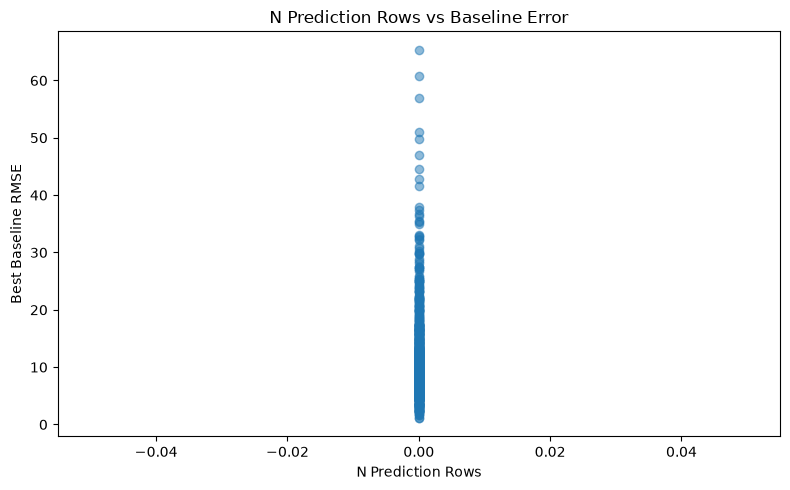

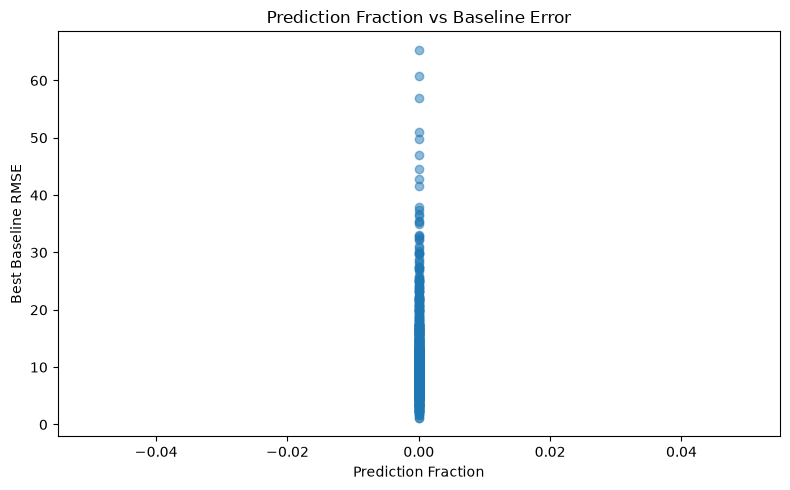

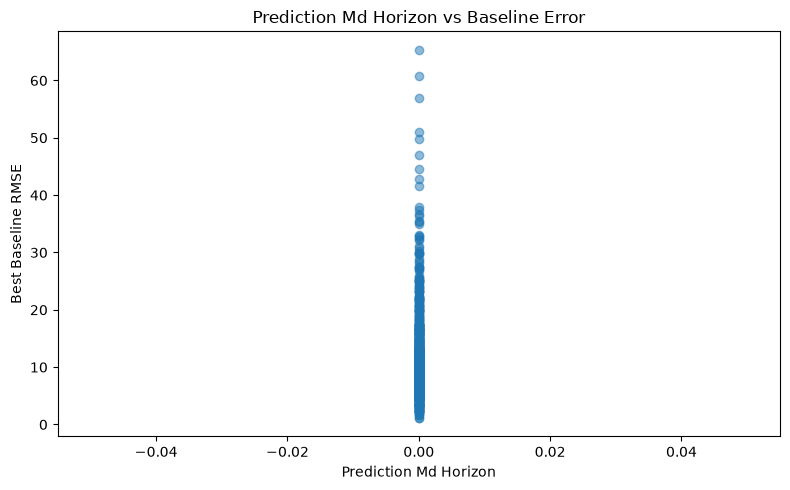

In [120]:
for feature in top_failure_features:
    plot_df = failure_analysis_df[
        [feature, "best_baseline_rmse"]
    ].dropna()

    plt.figure(figsize=(8, 5))

    plt.scatter(
        plot_df[feature],
        plot_df["best_baseline_rmse"],
        alpha=0.5
    )

    plt.xlabel(feature.replace("_", " ").title())
    plt.ylabel("Best Baseline RMSE")
    plt.title(
        f"{feature.replace('_', ' ').title()} vs Baseline Error"
    )

    plt.tight_layout()
    plt.show()

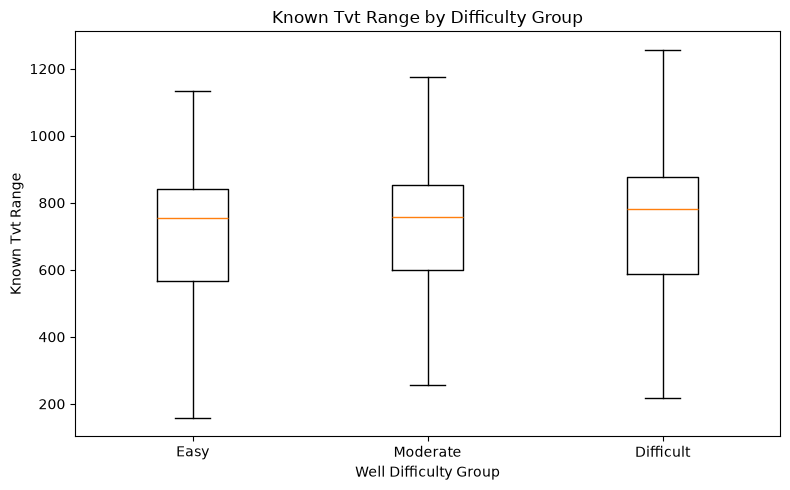

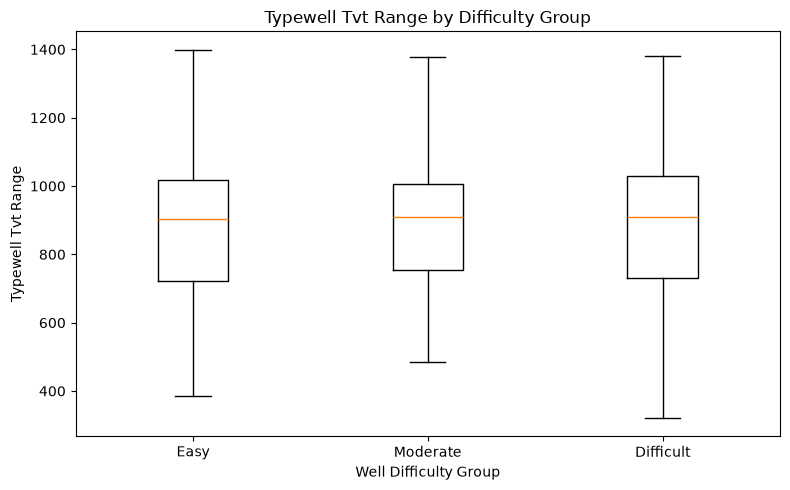

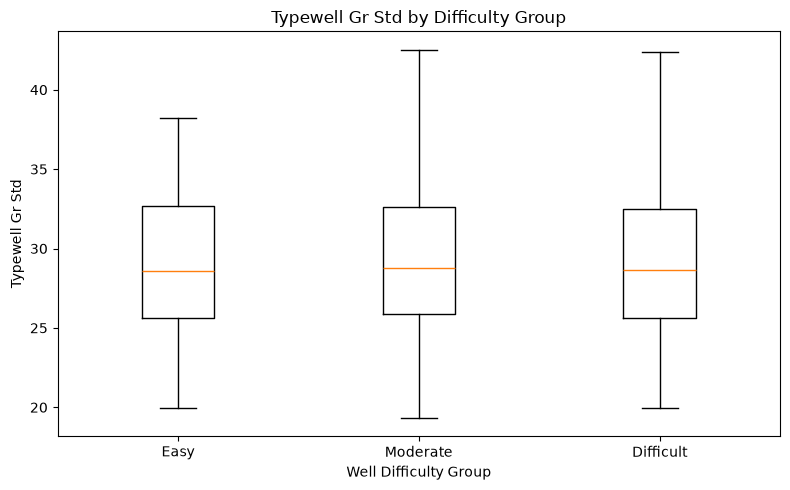

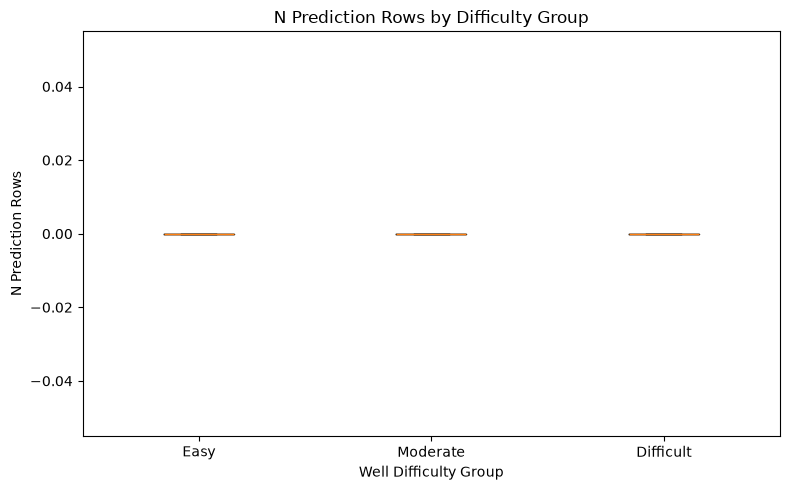

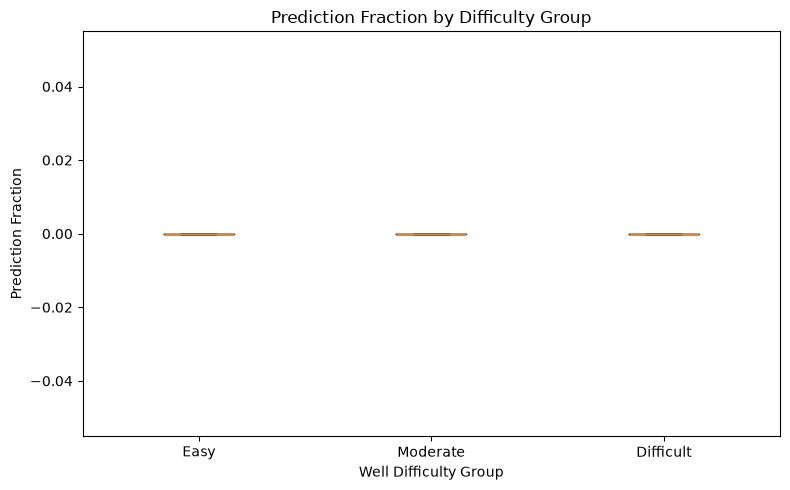

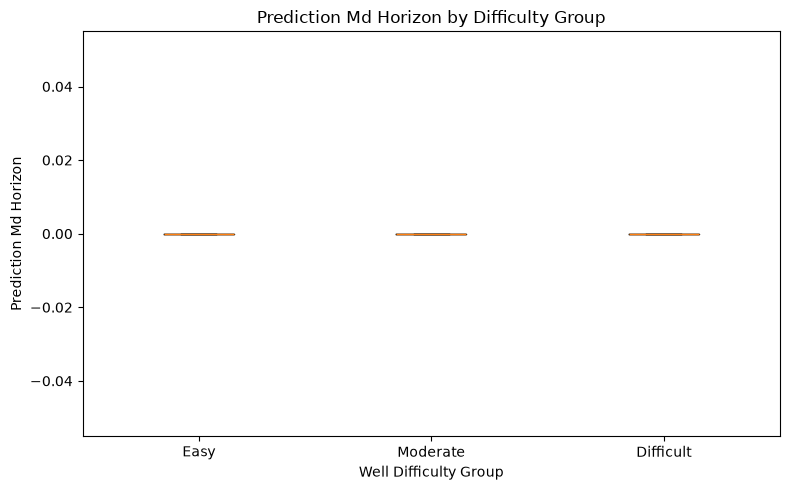

In [122]:
difficulty_order = ["Easy", "Moderate", "Difficult"]

for feature in top_failure_features:
    plot_data = [
        failure_analysis_df.loc[
            failure_analysis_df["difficulty_group"] == group,
            feature
        ].dropna()
        for group in difficulty_order
    ]

    plt.figure(figsize=(8, 5))

    plt.boxplot(
        plot_data,
        tick_labels=difficulty_order,
        showfliers=False
    )

    plt.xlabel("Well Difficulty Group")
    plt.ylabel(feature.replace("_", " ").title())
    plt.title(
        f"{feature.replace('_', ' ').title()} by Difficulty Group"
    )

    plt.tight_layout()
    plt.show()

#### 13.7 Identify the Most Difficult Wells

The most difficult wells are wells where every available baseline model performs poorly.

These wells are especially valuable because they reveal limitations that cannot be solved by simply selecting a different baseline.

In [123]:
difficult_wells_df = (
    failure_analysis_df
    .sort_values("best_baseline_rmse", ascending=False)
    .head(20)
)

display_columns = [
    "well_id",
    "best_baseline_model",
    "best_baseline_rmse",
    "prediction_md_horizon",
    "n_prediction_rows",
    "tvt_input_range",
    "prediction_gr_std",
    "gr_mean_difference",
    "formation_marker_coverage",
]

display_columns = [
    column
    for column in display_columns
    if column in difficult_wells_df.columns
]

difficult_wells_df[display_columns]

,well_id,best_baseline_model,best_baseline_rmse,prediction_md_horizon,n_prediction_rows,tvt_input_range,prediction_gr_std,gr_mean_difference,formation_marker_coverage
506,a959858c_,RMSE_Last_Known_TVT,65.3587,0.0000,0,NaN,NaN,NaN,0.0000
145,2fd68f7b_,RMSE_Last_Known_TVT,60.7402,0.0000,0,NaN,NaN,NaN,0.0000
285,5f4d2a52_,RMSE_Last_Known_TVT,56.9149,0.0000,0,NaN,NaN,NaN,0.0000
551,ba48188d_,RMSE_Last_Known_TVT,50.9372,0.0000,0,NaN,NaN,NaN,0.0000
168,389ae58f_,RMSE_Last_Known_TVT,49.7630,0.0000,0,NaN,NaN,NaN,0.0000
743,f6d009f4_,RMSE_Last_Known_TVT,47.0392,0.0000,0,NaN,NaN,NaN,0.0000
769,fef8af96_,RMSE_Last_Known_TVT,44.5517,0.0000,0,NaN,NaN,NaN,0.0000
592,c8d9680c_,RMSE_Last_Known_TVT,42.7704,0.0000,0,NaN,NaN,NaN,0.0000
754,fb03ae90_,RMSE_Z_to_TVT_Linear_Model,41.5980,0.0000,0,NaN,NaN,NaN,0.0000
104,25050f63_,RMSE_Last_Known_TVT,37.9966,0.0000,0,NaN,NaN,NaN,0.0000


In [124]:
most_difficult_well_ids = difficult_wells_df["well_id"].tolist()

most_difficult_well_ids[:10]

['a959858c_',
 '2fd68f7b_',
 '5f4d2a52_',
 'ba48188d_',
 '389ae58f_',
 'f6d009f4_',
 'fef8af96_',
 'c8d9680c_',
 'fb03ae90_',
 '25050f63_']

#### 13.8 Which Baseline Wins Under Different Conditions?

Different baseline models may be suitable for different types of wells.

This analysis checks whether the winning baseline changes according to:

- Prediction horizon
- TVT_input variation
- Gamma-ray variability
- Formation-marker coverage

This may indicate that an ensemble or model-selection strategy could outperform a single global baseline.

In [125]:
failure_analysis_df["best_baseline_model"].value_counts()

best_baseline_model
RMSE_Last_Known_TVT              599
RMSE_Linear_Extrapolation_10      62
RMSE_Linear_Extrapolation_100     59
RMSE_Linear_Extrapolation_50      50
RMSE_Z_to_TVT_Linear_Model         3
Name: count, dtype: int64

In [126]:
baseline_win_percentage = (
    failure_analysis_df["best_baseline_model"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

baseline_win_percentage

best_baseline_model
RMSE_Last_Known_TVT             77.4900
RMSE_Linear_Extrapolation_10     8.0200
RMSE_Linear_Extrapolation_100    7.6300
RMSE_Linear_Extrapolation_50     6.4700
RMSE_Z_to_TVT_Linear_Model       0.3900
Name: proportion, dtype: float64

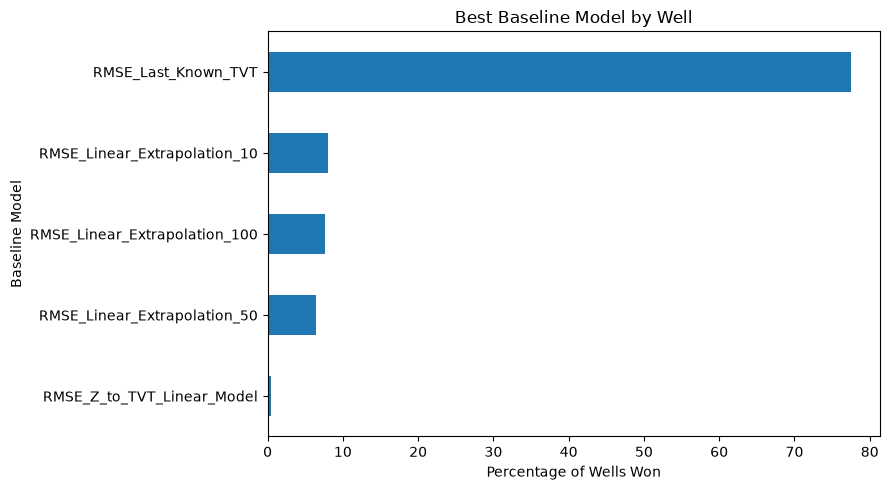

In [127]:
plt.figure(figsize=(9, 5))

baseline_win_percentage.sort_values().plot(
    kind="barh"
)

plt.xlabel("Percentage of Wells Won")
plt.ylabel("Baseline Model")
plt.title("Best Baseline Model by Well")
plt.tight_layout()
plt.show()

In [128]:
winning_model_summary_df = (
    failure_analysis_df
    .groupby("best_baseline_model")[
        available_analysis_features
    ]
    .median()
)

winning_model_summary_df

,n_prediction_rows,prediction_fraction,prediction_md_horizon,known_tvt_range,tvt_input_range,tvt_input_std,prediction_gr_mean,prediction_gr_std,prediction_gr_range,prediction_gr_missing_fraction,typewell_tvt_range,typewell_gr_std,gr_mean_difference,formation_marker_count,formation_marker_coverage
best_baseline_model,,,,,,,,,,,,,,,
RMSE_Last_Known_TVT,0.0000,0.0000,0.0000,762.3800,NaN,NaN,NaN,NaN,NaN,NaN,909.5000,28.6570,NaN,0.0000,0.0000
RMSE_Linear_Extrapolation_10,0.0000,0.0000,0.0000,779.5700,NaN,NaN,NaN,NaN,NaN,NaN,943.8450,29.1305,NaN,0.0000,0.0000
RMSE_Linear_Extrapolation_100,0.0000,0.0000,0.0000,731.2900,NaN,NaN,NaN,NaN,NaN,NaN,899.8100,29.1207,NaN,0.0000,0.0000
RMSE_Linear_Extrapolation_50,0.0000,0.0000,0.0000,757.6000,NaN,NaN,NaN,NaN,NaN,NaN,826.2500,28.5380,NaN,0.0000,0.0000
RMSE_Z_to_TVT_Linear_Model,0.0000,0.0000,0.0000,832.5200,NaN,NaN,NaN,NaN,NaN,NaN,992.0000,27.2216,NaN,0.0000,0.0000


#### 13.9 Feature Discovery Conclusions

The failure analysis confirms that baseline performance is **not the same across wells**. Even after choosing the best baseline for each well, RMSE ranged from about **1.1** to **65.4**, with a median of about **9.7**.

**What separates easy and difficult wells**

Wells were grouped by best-baseline RMSE into **194 Easy**, **385 Moderate**, and **194 Difficult** cases. The clearest difference in the current analysis was in the **known-section TVT range**: difficult wells had a slightly wider range (median about **782** vs **753** for easy wells). That suggests wells with more TVT movement before Prediction Start can be harder to predict with simple baselines.

The scatter plots and error curves from Section 12 support the same story: baselines work when TVT stays close to the last known value after Prediction Start, and fail when TVT keeps rising or falling.

**Which baseline wins where**

On a per-well basis, **Last Known TVT** was best for **599 of 773 wells (77.5%)**. Linear extrapolation won on the remaining wells, mostly with the **10-row window (62 wells)**. The Z model won on only **3 wells**, and **Formation Marker never won**.

So a single global baseline is not enough, but Last Known TVT is still the strongest default. Linear extrapolation may help on a minority of wells where the near-boundary trend continues.

**What the correlation analysis showed**

Among the well-level features tested here, the strongest link with error was a **weak positive correlation** for `known_tvt_range` (about **+0.09**). `typewell_tvt_range` and `typewell_gr_std` showed even weaker links. This means summary well features alone do not fully explain failure, and row-level modelling will be needed.

Based on the baseline results, example wells, and this failure analysis, the most promising directions are:

1. **Post-boundary TVT behaviour** - how much TVT changes after Prediction Start, and whether the recent trend continues
2. **Known-section TVT shape** - level, slope, and variability before Prediction Start
3. **Prediction-zone length** - longer hidden sections are harder to extrapolate
4. **Trajectory features** - X, Y, Z and local changes, especially where Z-only baselines failed
5. **Gamma-ray features** - useful only as part of a wider model because GR is often missing
6. **Typewell-linked features** - nearest typewell TVT/GR and differences from the horizontal well
7. **Formation-marker features** - low priority for now, since the formation baseline was by far the weakest method


### 14. Final Baseline Comparison

The previous sections evaluated each baseline model individually and investigated their failure patterns.

This section consolidates the evaluation results into a final comparison table, allowing the overall strengths and weaknesses of each baseline to be assessed.

The objectives are to:

- compare overall prediction accuracy across all baseline models,
- identify which baseline performs best on average,
- determine how consistently each baseline performs,
- measure how often each baseline is the best-performing model for a well, and
- establish a benchmark for future machine-learning models.

The resulting comparison provides the reference performance that all models developed in Notebook 05 should aim to exceed.

#### 14.1 Build Final Comparison Table

Performance is evaluated using several complementary statistics rather than relying on a single metric.

For each baseline model, the following are reported:

- Mean RMSE
- Median RMSE
- Standard deviation of RMSE
- Mean MAE
- Median MAE
- Standard deviation of MAE
- Number of evaluated wells

Together these statistics provide a more complete understanding of prediction quality and model stability.

In [136]:
baseline_models = {
    "Last Known TVT": {
        "rmse": "RMSE_Last_Known_TVT",
        "mae": "MAE_Last_Known_TVT",
    },
    "Linear Extrapolation (10)": {
        "rmse": "RMSE_Linear_Extrapolation_10",
        "mae": "MAE_Linear_Extrapolation_10",
    },
    "Linear Extrapolation (50)": {
        "rmse": "RMSE_Linear_Extrapolation_50",
        "mae": "MAE_Linear_Extrapolation_50",
    },
    "Linear Extrapolation (100)": {
        "rmse": "RMSE_Linear_Extrapolation_100",
        "mae": "MAE_Linear_Extrapolation_100",
    },
    "Z → TVT Linear": {
        "rmse": "RMSE_Z_to_TVT_Linear_Model",
        "mae": "MAE_Z_to_TVT_Linear_Model",
    },
    "Formation Marker": {
        "rmse": "RMSE_Formation_Marker_Baseline",
        "mae": "MAE_Formation_Marker_Baseline",
    },
}

In [139]:
comparison_records = []

for model_name, cols in baseline_models.items():

    rmse = failure_analysis_df[cols["rmse"]]
    mae = failure_analysis_df[cols["mae"]]

    comparison_records.append({
        "Model": model_name,

        "Mean RMSE": rmse.mean(),
        "Median RMSE": rmse.median(),
        "RMSE Std": rmse.std(),

        "Mean MAE": mae.mean(),
        "Median MAE": mae.median(),
        "MAE Std": mae.std(),

        "Evaluated Wells": rmse.notna().sum()
    })

comparison_df = pd.DataFrame(comparison_records)

comparison_df

,Model,Mean RMSE,Median RMSE,RMSE Std,Mean MAE,Median MAE,MAE Std,Evaluated Wells
0,Last Known TVT,12.8125,10.6651,8.8995,10.9323,8.7286,8.1367,773
1,Linear Extrapolation (10),58.1355,37.2149,80.4469,49.3559,30.5816,69.1215,773
2,Linear Extrapolation (50),60.6829,37.9880,87.2597,51.6731,32.4676,75.0689,773
3,Linear Extrapolation (100),60.1914,36.7085,91.0576,51.2812,32.1667,78.3628,773
4,Z → TVT Linear,110.8777,107.1353,41.3900,99.6183,96.2368,37.1761,773
5,Formation Marker,"1,017.9323",893.8264,676.5793,903.6561,801.0324,592.5908,773


#### 14.2 Rank Baseline Models

The baseline models are ranked according to their average RMSE, since RMSE is the primary competition metric and penalises large prediction errors more heavily than MAE.

Lower RMSE indicates better predictive performance.

In [142]:
comparison_df = comparison_df.sort_values(
    "Mean RMSE"
).reset_index(drop=True)

comparison_df["Rank"] = np.arange(
    1,
    len(comparison_df)+1
)

comparison_df

,Model,Mean RMSE,Median RMSE,RMSE Std,Mean MAE,Median MAE,MAE Std,Evaluated Wells,Rank
0,Last Known TVT,12.8125,10.6651,8.8995,10.9323,8.7286,8.1367,773,1
1,Linear Extrapolation (10),58.1355,37.2149,80.4469,49.3559,30.5816,69.1215,773,2
2,Linear Extrapolation (100),60.1914,36.7085,91.0576,51.2812,32.1667,78.3628,773,3
3,Linear Extrapolation (50),60.6829,37.9880,87.2597,51.6731,32.4676,75.0689,773,4
4,Z → TVT Linear,110.8777,107.1353,41.3900,99.6183,96.2368,37.1761,773,5
5,Formation Marker,"1,017.9323",893.8264,676.5793,903.6561,801.0324,592.5908,773,6


#### 14.3 Winning Baseline Frequency

Average performance does not necessarily indicate which model performs best on individual wells.

This analysis counts how frequently each baseline achieves the lowest RMSE across all wells.

A model that wins frequently is likely to generalise well across different geological conditions, whereas a model with fewer wins may only perform well under specific circumstances.

In [144]:
rmse_col_to_model = {
    cols["rmse"]: model_name
    for model_name, cols in baseline_models.items()
}

rmse_cols = [
    col for col in rmse_col_to_model
    if col in failure_analysis_df.columns
]

best_rmse_col = failure_analysis_df[rmse_cols].idxmin(axis=1)

winner_counts = (
    best_rmse_col
    .map(rmse_col_to_model)
    .value_counts()
    .rename_axis("Model")
    .reset_index(name="Winning Wells")
)

winner_counts["Winning Percentage"] = (
    winner_counts["Winning Wells"]
    / len(failure_analysis_df)
    * 100
)

winner_counts


,Model,Winning Wells,Winning Percentage
0,Last Known TVT,599,77.4903
1,Linear Extrapolation (10),62,8.0207
2,Linear Extrapolation (100),59,7.6326
3,Linear Extrapolation (50),50,6.4683
4,Z → TVT Linear,3,0.3881


#### 14.4 Merge Everything Together

In [145]:
comparison_df = comparison_df.merge(
    winner_counts,
    on="Model",
    how="left"
)

comparison_df["Winning Wells"] = (
    comparison_df["Winning Wells"]
    .fillna(0)
    .astype(int)
)

comparison_df["Winning Percentage"] = (
    comparison_df["Winning Percentage"]
    .fillna(0)
)

comparison_df

,Model,Mean RMSE,Median RMSE,RMSE Std,Mean MAE,Median MAE,MAE Std,Evaluated Wells,Rank,Winning Wells,Winning Percentage
0,Last Known TVT,12.8125,10.6651,8.8995,10.9323,8.7286,8.1367,773,1,599,77.4903
1,Linear Extrapolation (10),58.1355,37.2149,80.4469,49.3559,30.5816,69.1215,773,2,62,8.0207
2,Linear Extrapolation (100),60.1914,36.7085,91.0576,51.2812,32.1667,78.3628,773,3,59,7.6326
3,Linear Extrapolation (50),60.6829,37.9880,87.2597,51.6731,32.4676,75.0689,773,4,50,6.4683
4,Z → TVT Linear,110.8777,107.1353,41.3900,99.6183,96.2368,37.1761,773,5,3,0.3881
5,Formation Marker,"1,017.9323",893.8264,676.5793,903.6561,801.0324,592.5908,773,6,0,0.0000


#### 14.5 Visual Comparison

The following visualisations compare baseline performance from different perspectives.

The first figure compares average prediction accuracy, while the second illustrates how frequently each baseline achieves the best prediction for an individual well.

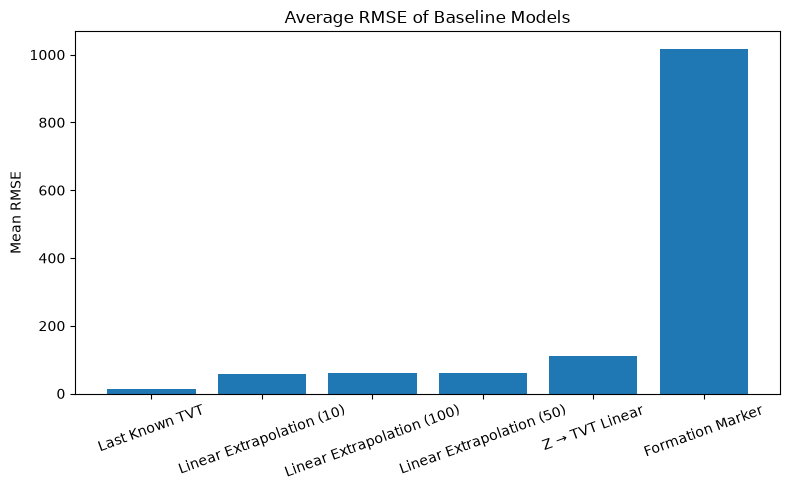

In [146]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Mean RMSE"]
)

plt.ylabel("Mean RMSE")
plt.title("Average RMSE of Baseline Models")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

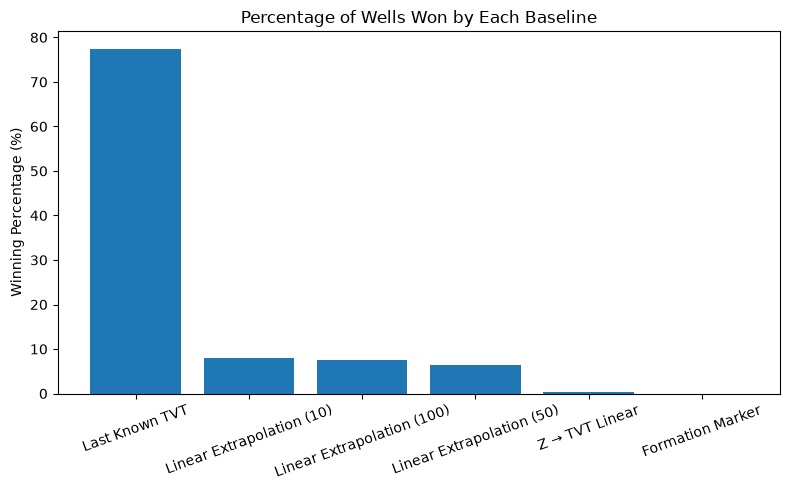

In [147]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Winning Percentage"]
)

plt.ylabel("Winning Percentage (%)")

plt.title("Percentage of Wells Won by Each Baseline")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

#### 14.6 Best Baseline Summary

Across all **773** evaluated wells, **Last Known TVT** is the strongest baseline by a wide margin. It achieves the lowest mean RMSE (**12.8**) and median RMSE (**10.7**), and is the best model for **599 wells (77.5%)**. Its error spread is also the most stable (RMSE std ≈ **8.9**), so it is the clear default benchmark for Notebook 05.

Linear extrapolation is a distant second. The **10-row** window is the best of the three variants (mean RMSE ≈ **58**, **62** wins), with the 50- and 100-row windows close behind. Together, the linear methods win on about **22%** of wells, which suggests they help mainly where the recent TVT trend continues past Prediction Start.

**Z → TVT Linear** is much weaker (mean RMSE ≈ **111**, only **3** wins). **Formation Marker** is not competitive (mean RMSE ≈ **1,018**, **0** wins) and should not be used as a benchmark.

Even with the best baseline per well, prediction difficulty still varies a lot across wells. That gap is what machine-learning models in Notebook 05 need to close: beat Last Known TVT on average, and improve on the remaining wells where simple carry-forward or short-trend extrapolation fail.


### 15. Save Results

The analyses performed in this notebook generate several datasets that are useful for future modelling and reproducibility.

Rather than recalculating these outputs in later notebooks, they are saved to the project's processed data directory.

The following files are exported:

- **Baseline well-level results** – prediction performance for every well.
- **Baseline comparison summary** – overall performance statistics for each baseline model.
- **Failure analysis dataset** – well characteristics combined with baseline errors.
- **Most difficult wells** – wells with the highest prediction errors for further investigation.

These files will be used as reference inputs during the machine-learning experiments in Notebook 05.

#### 15.1 Configure Output Directory

All exported datasets are stored in the project's `data/processed` directory.

In [148]:
OUTPUT_DIR = PROCESSED_DIR

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Output directory:")
print(OUTPUT_DIR)

Output directory:
..\data\processed


#### 15.2 Save Well-Level Baseline Results

In [149]:
baseline_results_path = (
    OUTPUT_DIR / "notebook_04_well_results.csv"
)

baseline_results_df.to_csv(
    baseline_results_path,
    index=False
)

print(baseline_results_path)

..\data\processed\notebook_04_well_results.csv


#### 15.3 Save Baseline Comparison Summary

In [150]:
comparison_summary_path = (
    OUTPUT_DIR / "notebook_04_baseline_summary.csv"
)

comparison_df.to_csv(
    comparison_summary_path,
    index=False
)

print(comparison_summary_path)

..\data\processed\notebook_04_baseline_summary.csv


#### 15.4 Save Failure Analysis Dataset

In [151]:
failure_analysis_path = (
    OUTPUT_DIR / "notebook_04_failure_analysis.csv"
)

failure_analysis_df.to_csv(
    failure_analysis_path,
    index=False
)

print(failure_analysis_path)

..\data\processed\notebook_04_failure_analysis.csv


#### 15.5 Save Difficult Wells

In [152]:
difficult_wells_path = (
    OUTPUT_DIR / "notebook_04_difficult_wells.csv"
)

difficult_wells_df.to_csv(
    difficult_wells_path,
    index=False
)

print(difficult_wells_path)

..\data\processed\notebook_04_difficult_wells.csv


#### 15.6 Verify Saved Files

In [154]:
saved_files = {
    "Well Results": baseline_results_path,
    "Baseline Summary": comparison_summary_path,
    "Failure Analysis": failure_analysis_path,
    "Difficult Wells": difficult_wells_path,
}

verification_records = []

for name, path in saved_files.items():

    verification_records.append({
        "Dataset": name,
        "Exists": path.exists(),
        "File": path.name
    })

verification_df = pd.DataFrame(
    verification_records
)

verification_df

,Dataset,Exists,File
0,Well Results,True,notebook_04_well_results.csv
1,Baseline Summary,True,notebook_04_baseline_summary.csv
2,Failure Analysis,True,notebook_04_failure_analysis.csv
3,Difficult Wells,True,notebook_04_difficult_wells.csv


In [155]:
assert verification_df["Exists"].all(), (
    "One or more output files were not saved successfully."
)

print("All Notebook 04 outputs were saved successfully.")

All Notebook 04 outputs were saved successfully.


### 16. Notebook Conclusions

#### 16.1 Notebook Summary

This notebook established a benchmark framework for predicting missing True Vertical Thickness (TVT) values in horizontal wells. Four baseline methods were implemented: **Last Known TVT**, **Linear Extrapolation** (10-, 50-, and 100-row windows), **Z → TVT Linear Model**, and **Formation Marker Baseline**.

A common validation pipeline was applied to all **773** complete training well pairs. Predictions were restricted to the hidden section (rows where `TVT_input` is absent), and each model was scored with **MAE**, **RMSE**, and **bias** at both well and row level.

Every training well was evaluated. Baselines were compared using aggregate statistics (mean, median, standard deviation, weighted metrics, and per-well win counts). Representative wells (low, median, and high error) were examined to characterise prediction behaviour. Failure analysis linked well-level characteristics to baseline errors and identified features for subsequent modelling.

Processed outputs (`notebook_04_well_results.csv`, `notebook_04_baseline_summary.csv`, `notebook_04_failure_analysis.csv`) were saved for Notebook 05.

#### 16.2 Key Findings

**Best overall baseline.** **Last Known TVT** achieved the lowest average performance across all metrics: median MAE **8.73**, median RMSE **10.67**, mean RMSE **12.81**, and weighted MAE **11.20** (weighted RMSE **15.91**). It was the best model on **599 of 773 wells (77.5%)** and showed the most stable error distribution (RMSE std ≈ **8.9**).

**Relative ranking.** No other baseline approached this level of accuracy. Linear Extrapolation (10-row window) was the strongest alternative (median MAE **30.58**, mean RMSE **58.14**, **62** wins). The 50- and 100-row variants performed similarly but slightly worse. The Z → TVT model was substantially weaker (median MAE **96.24**, mean RMSE **110.88**, **3** wins). Formation Marker Baseline was not competitive (median MAE **801.03**, weighted MAE **964.89**, **0** wins), with large positive bias indicating systematic over-prediction.

**Consistency.** Last Known TVT dominated on most wells; linear extrapolation helped only where the near-boundary TVT trend continued into the prediction section (~**22%** of wells). A single global baseline is therefore insufficient, but Last Known TVT is the appropriate default benchmark.

**Well difficulty.** Performance varied markedly even with the best available baseline per well: best-baseline RMSE ranged from **~1.1** to **~65.4** (median **~9.7**). Wells were classified as **194 Easy**, **385 Moderate**, and **194 Difficult**. Difficult wells showed a slightly wider known-section TVT range (median **~782** vs **~753** for easy wells). Correlation with `known_tvt_range` was weak but positive (**~+0.09**); well-level summaries alone did not fully explain failure.

**Behavioural pattern.** Baselines succeeded when TVT remained approximately flat after Prediction Start. They failed when TVT continued to rise or fall, when the Z–TVT relationship changed post-boundary, or when formation markers did not track horizontal TVT in the hidden section.

#### 16.3 Limitations of Baseline Models

The baselines are deliberately simple and impose structural constraints that limit predictive capacity:

- **Linear assumptions.** Linear extrapolation and Z → TVT mapping assume that pre-boundary trends or relationships persist unchanged.
- **No learning from data.** Parameters are not fitted across wells; each well is treated independently with fixed rules.
- **No nonlinear geology.** Stratigraphic complexity, facies transitions, and nonlinear TVT variation are not modelled.
- **No multivariate interactions.** GR, TVT, trajectory (X, Y, Z), formation markers, and typewell information are not combined; each signal is used in isolation.
- **Independent point predictions.** Baselines do not capture sequential or spatial dependencies along the wellbore.

These limitations explain why even the best baseline leaves substantial residual error on difficult wells and justify more advanced approaches in Notebook 05.

#### 16.4 Implications for Machine Learning

Failure analysis identified six feature categories to engineer for ML models:

| Category | Content |
|---|---|
| *Trajectory features* | X, Y, Z and local geometric changes along the wellbore |
| *TVT_input features* | Known-section level, slope, variability, and post-boundary behaviour |
| *Gamma-ray features* | GR values and missing-data indicators (GR is frequently absent) |
| *Formation-marker features* | Formation-column values and validation-set fit quality |
| *Typewell relationship features* | Nearest typewell TVT/GR and horizontal–typewell differences |
| *Spatial and geometric features* | Prediction-zone length, TVT range, typewell coverage, and coordinate-based context |

Well-level summaries provide coarse difficulty signals; row-level features derived from these categories are expected to support models that adapt to local geology rather than applying a single global rule.

#### 16.5 Next Steps

Notebook 05 will:

1. Load processed datasets and baseline benchmark results from this notebook.
2. Construct a row-level feature matrix from the categories above.
3. Implement a train/validation pipeline with leakage-safe splits.
4. Train ML models (e.g., Random Forest, Gradient Boosting, XGBoost).
5. Perform hyperparameter tuning and cross-validation.
6. Compare ML performance against **Last Known TVT** (median RMSE **10.67**) as the primary benchmark.
7. Generate Kaggle submission predictions for the test set.

The objective is to exceed baseline accuracy on average and, in particular, to reduce error on the **~25%** of wells where simple carry-forward or short-trend extrapolation remains inadequate.